## **Connect Colab**

In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "xx"
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"] = "xx"

In [3]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 12 file(s) under /src/
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/pretrained.py
src/utils/save.py -> /content/src/utils/save.py

 All files saved under /content/src/
Contents of /content/src/:
/content/src/cl_strategies/naive.py
/content/src/cl_strategies/reharsa

## **Download DATASET**

In [4]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh  # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [5]:
# imports
%run /content/src/imports.py
criterion = nn.CrossEntropyLoss()

Using device: cuda


## **Study Dataset**

  Loaded train: 10,055 rows
  Loaded val  : 1,673 rows
  Loaded test : 1,723 rows
  Total videos  : 13,451
  Total classes : 101

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13451 entries, 0 to 13450
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   clip_name  13451 non-null  object
 1   clip_path  13451 non-null  object
 2   label      13451 non-null  object
dtypes: object(3)
memory usage: 315.4+ KB


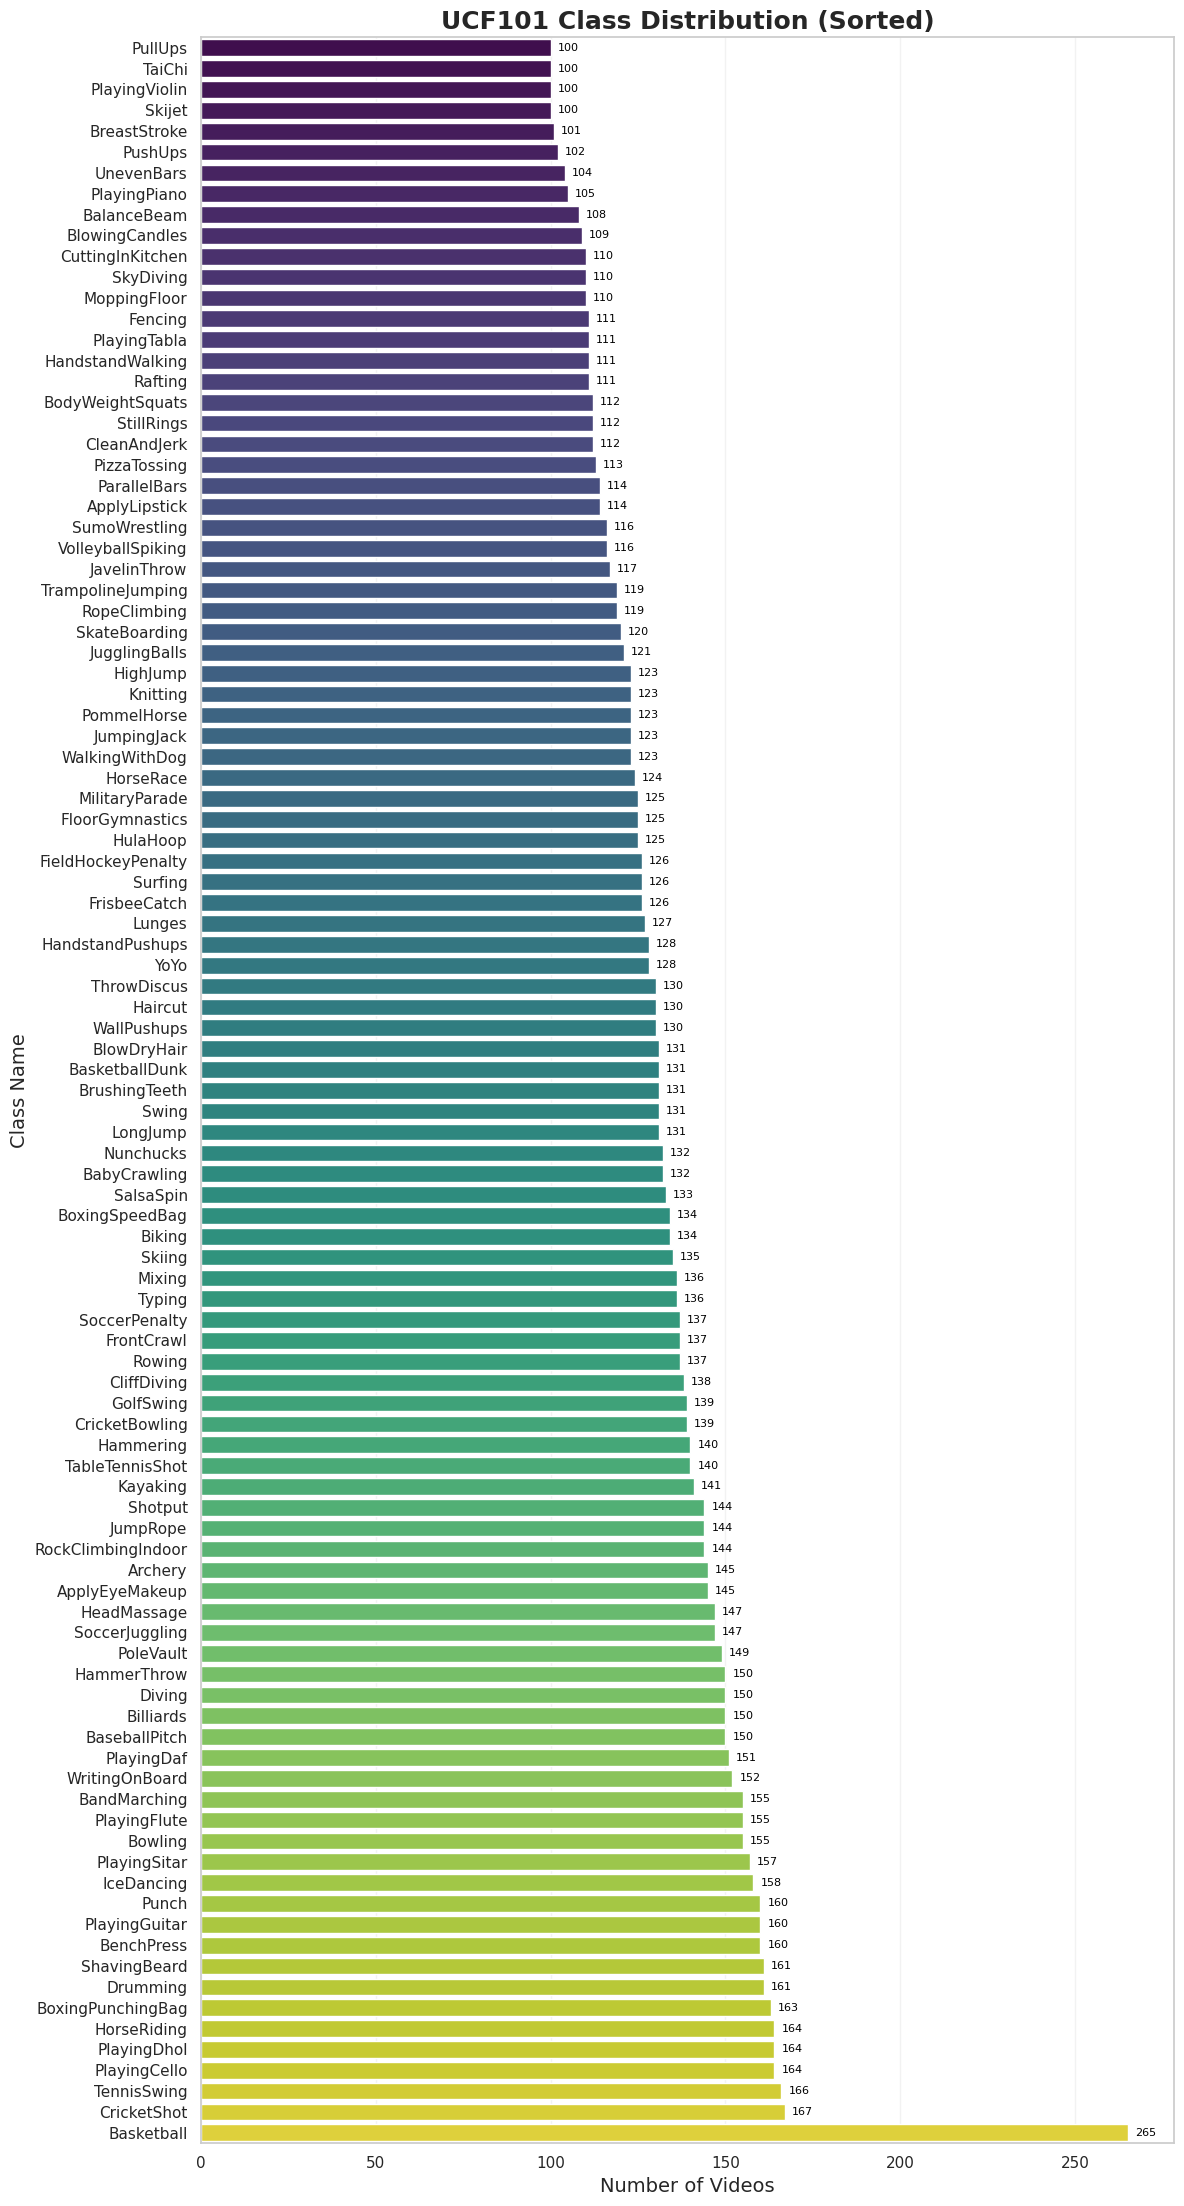

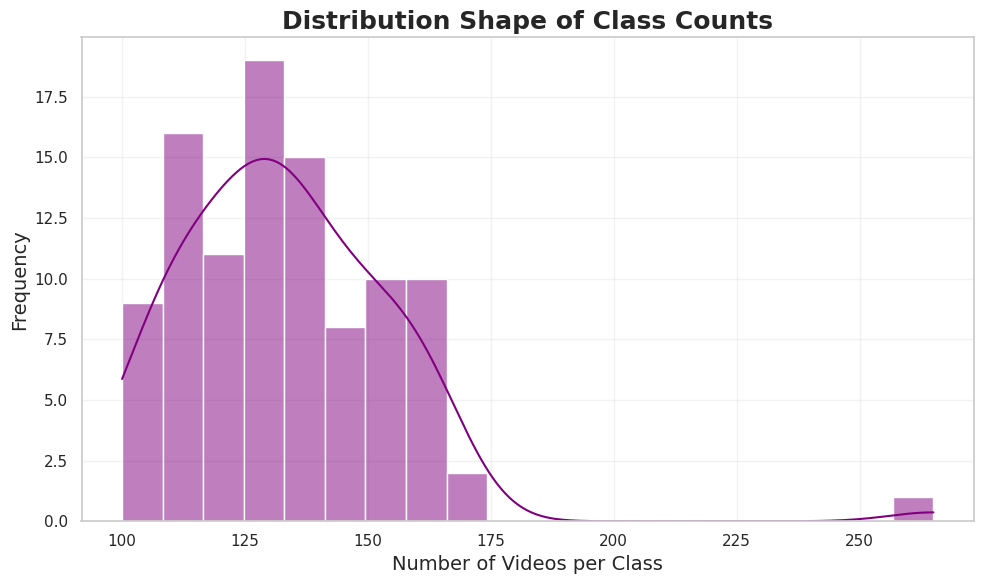

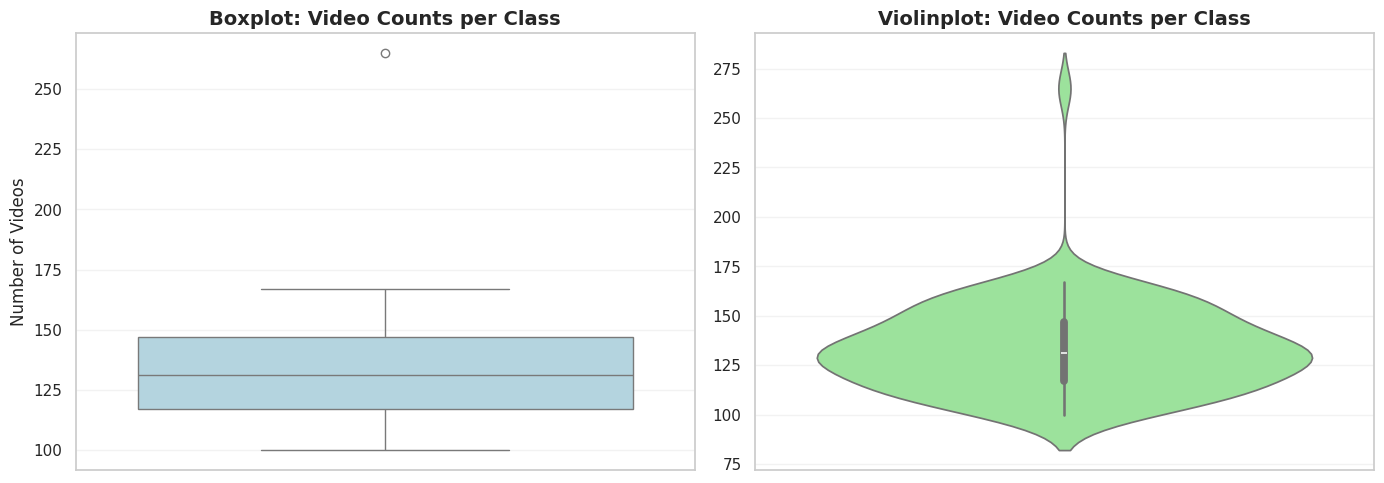


Outlier Classes Detected (IQR Method):
     Class  Count
Basketball    265


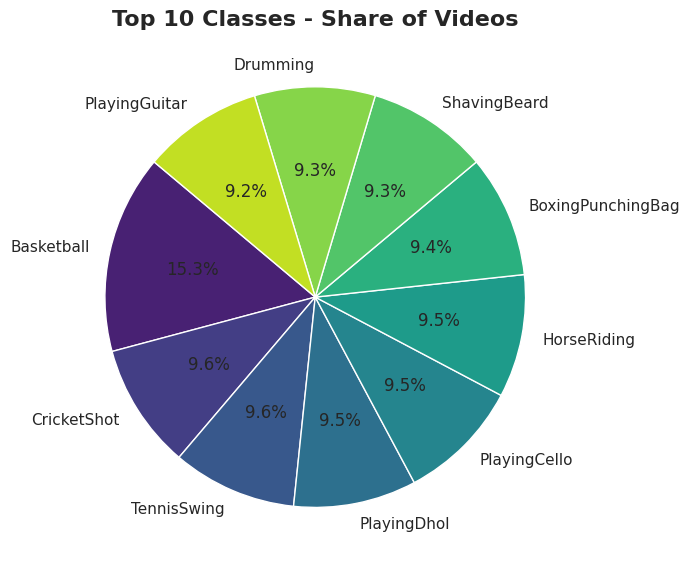


Class Balance Score (std/mean): 0.170
  Dataset is moderately balanced.


In [6]:
study = DatasetStudy()
study.run_all()

## **Preprocess the data**

In [7]:
preprocess_dataset()


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : /kaggle/working/ucf101-processed/
Classes: 10 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /kaggle/working/ucf101-processed/


## **DataLoaders**

In [8]:
class_to_idx_10 = {cls: i for i, cls in enumerate(SELECTED_CLASSES)}
print(class_to_idx_10)

TRAIN_DIR = os.path.join(OUTPUT_ROOT, "train")
VAL_DIR = os.path.join(OUTPUT_ROOT, "val")
TEST_DIR = os.path.join(OUTPUT_ROOT, "test")

train_dataset_10 = UCF101Clips(
    TRAIN_DIR,
    class_to_idx_10
)

val_dataset_10 = UCF101Clips(
    VAL_DIR,
    class_to_idx_10
)

test_dataset_10 = UCF101Clips(
    TEST_DIR,
    class_to_idx_10
)

train_loader_10 = DataLoader(train_dataset_10, batch_size=BATCH_SIZE, shuffle=True)
val_loader_10   = DataLoader(val_dataset_10, batch_size=BATCH_SIZE, shuffle=False)
test_loader_10  = DataLoader(test_dataset_10, batch_size=BATCH_SIZE, shuffle=False)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9}


## **CUSTOM CNN + LSTM**

In [9]:
# Instantiate the model
custom_cnn = ScratchCNNLSTM()

In [10]:
# Inspect the model's architecture
summary(custom_cnn, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ScratchCNNLSTM                           [1, 10]                   --
├─Conv2d: 1-1                            [16, 32, 224, 224]        896
├─MaxPool2d: 1-2                         [16, 32, 112, 112]        --
├─Conv2d: 1-3                            [16, 64, 112, 112]        18,496
├─MaxPool2d: 1-4                         [16, 64, 56, 56]          --
├─Conv2d: 1-5                            [16, 128, 56, 56]         73,856
├─MaxPool2d: 1-6                         [16, 128, 28, 28]         --
├─LSTM: 1-7                              [1, 16, 256]              103,024,640
├─Linear: 1-8                            [1, 10]                   2,570
Total params: 103,120,458
Trainable params: 103,120,458
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.79
Input size (MB): 9.63
Forward/backward pass size (MB): 359.69
Params size (MB): 412.48
Estimated Total Size (MB): 781.81

In [11]:
# Train the custom model
custom_cnn_results = train_model(custom_cnn, train_loader_10, val_loader_10, num_epochs=10)

Epoch [1/10] | Train Acc: 0.3662 Loss: 1.9302 | Val Acc: 0.4727 Loss: 1.6767


Epoch [2/10] | Train Acc: 0.6650 Loss: 1.3046 | Val Acc: 0.6061 Loss: 1.3153


Epoch [3/10] | Train Acc: 0.7837 Loss: 0.9351 | Val Acc: 0.7030 Loss: 1.0748


Epoch [4/10] | Train Acc: 0.8561 Loss: 0.7132 | Val Acc: 0.7879 Loss: 0.9195


Epoch [5/10] | Train Acc: 0.8974 Loss: 0.5394 | Val Acc: 0.7697 Loss: 0.7890


Epoch [6/10] | Train Acc: 0.9235 Loss: 0.4147 | Val Acc: 0.8182 Loss: 0.7177


Epoch [7/10] | Train Acc: 0.9577 Loss: 0.3181 | Val Acc: 0.8485 Loss: 0.6192


Epoch [8/10] | Train Acc: 0.9799 Loss: 0.2332 | Val Acc: 0.8727 Loss: 0.5733


Epoch [9/10] | Train Acc: 0.9829 Loss: 0.1766 | Val Acc: 0.8788 Loss: 0.5063


Epoch [10/10] | Train Acc: 0.9950 Loss: 0.1274 | Val Acc: 0.8909 Loss: 0.4753


In [12]:
test_acc_cust_cnn, all_preds_cust_cnn, all_labels_cust_cnn = test_model(custom_cnn, test_loader_10)

Running Inference on Test Set...


Test Accuracy: 0.8947


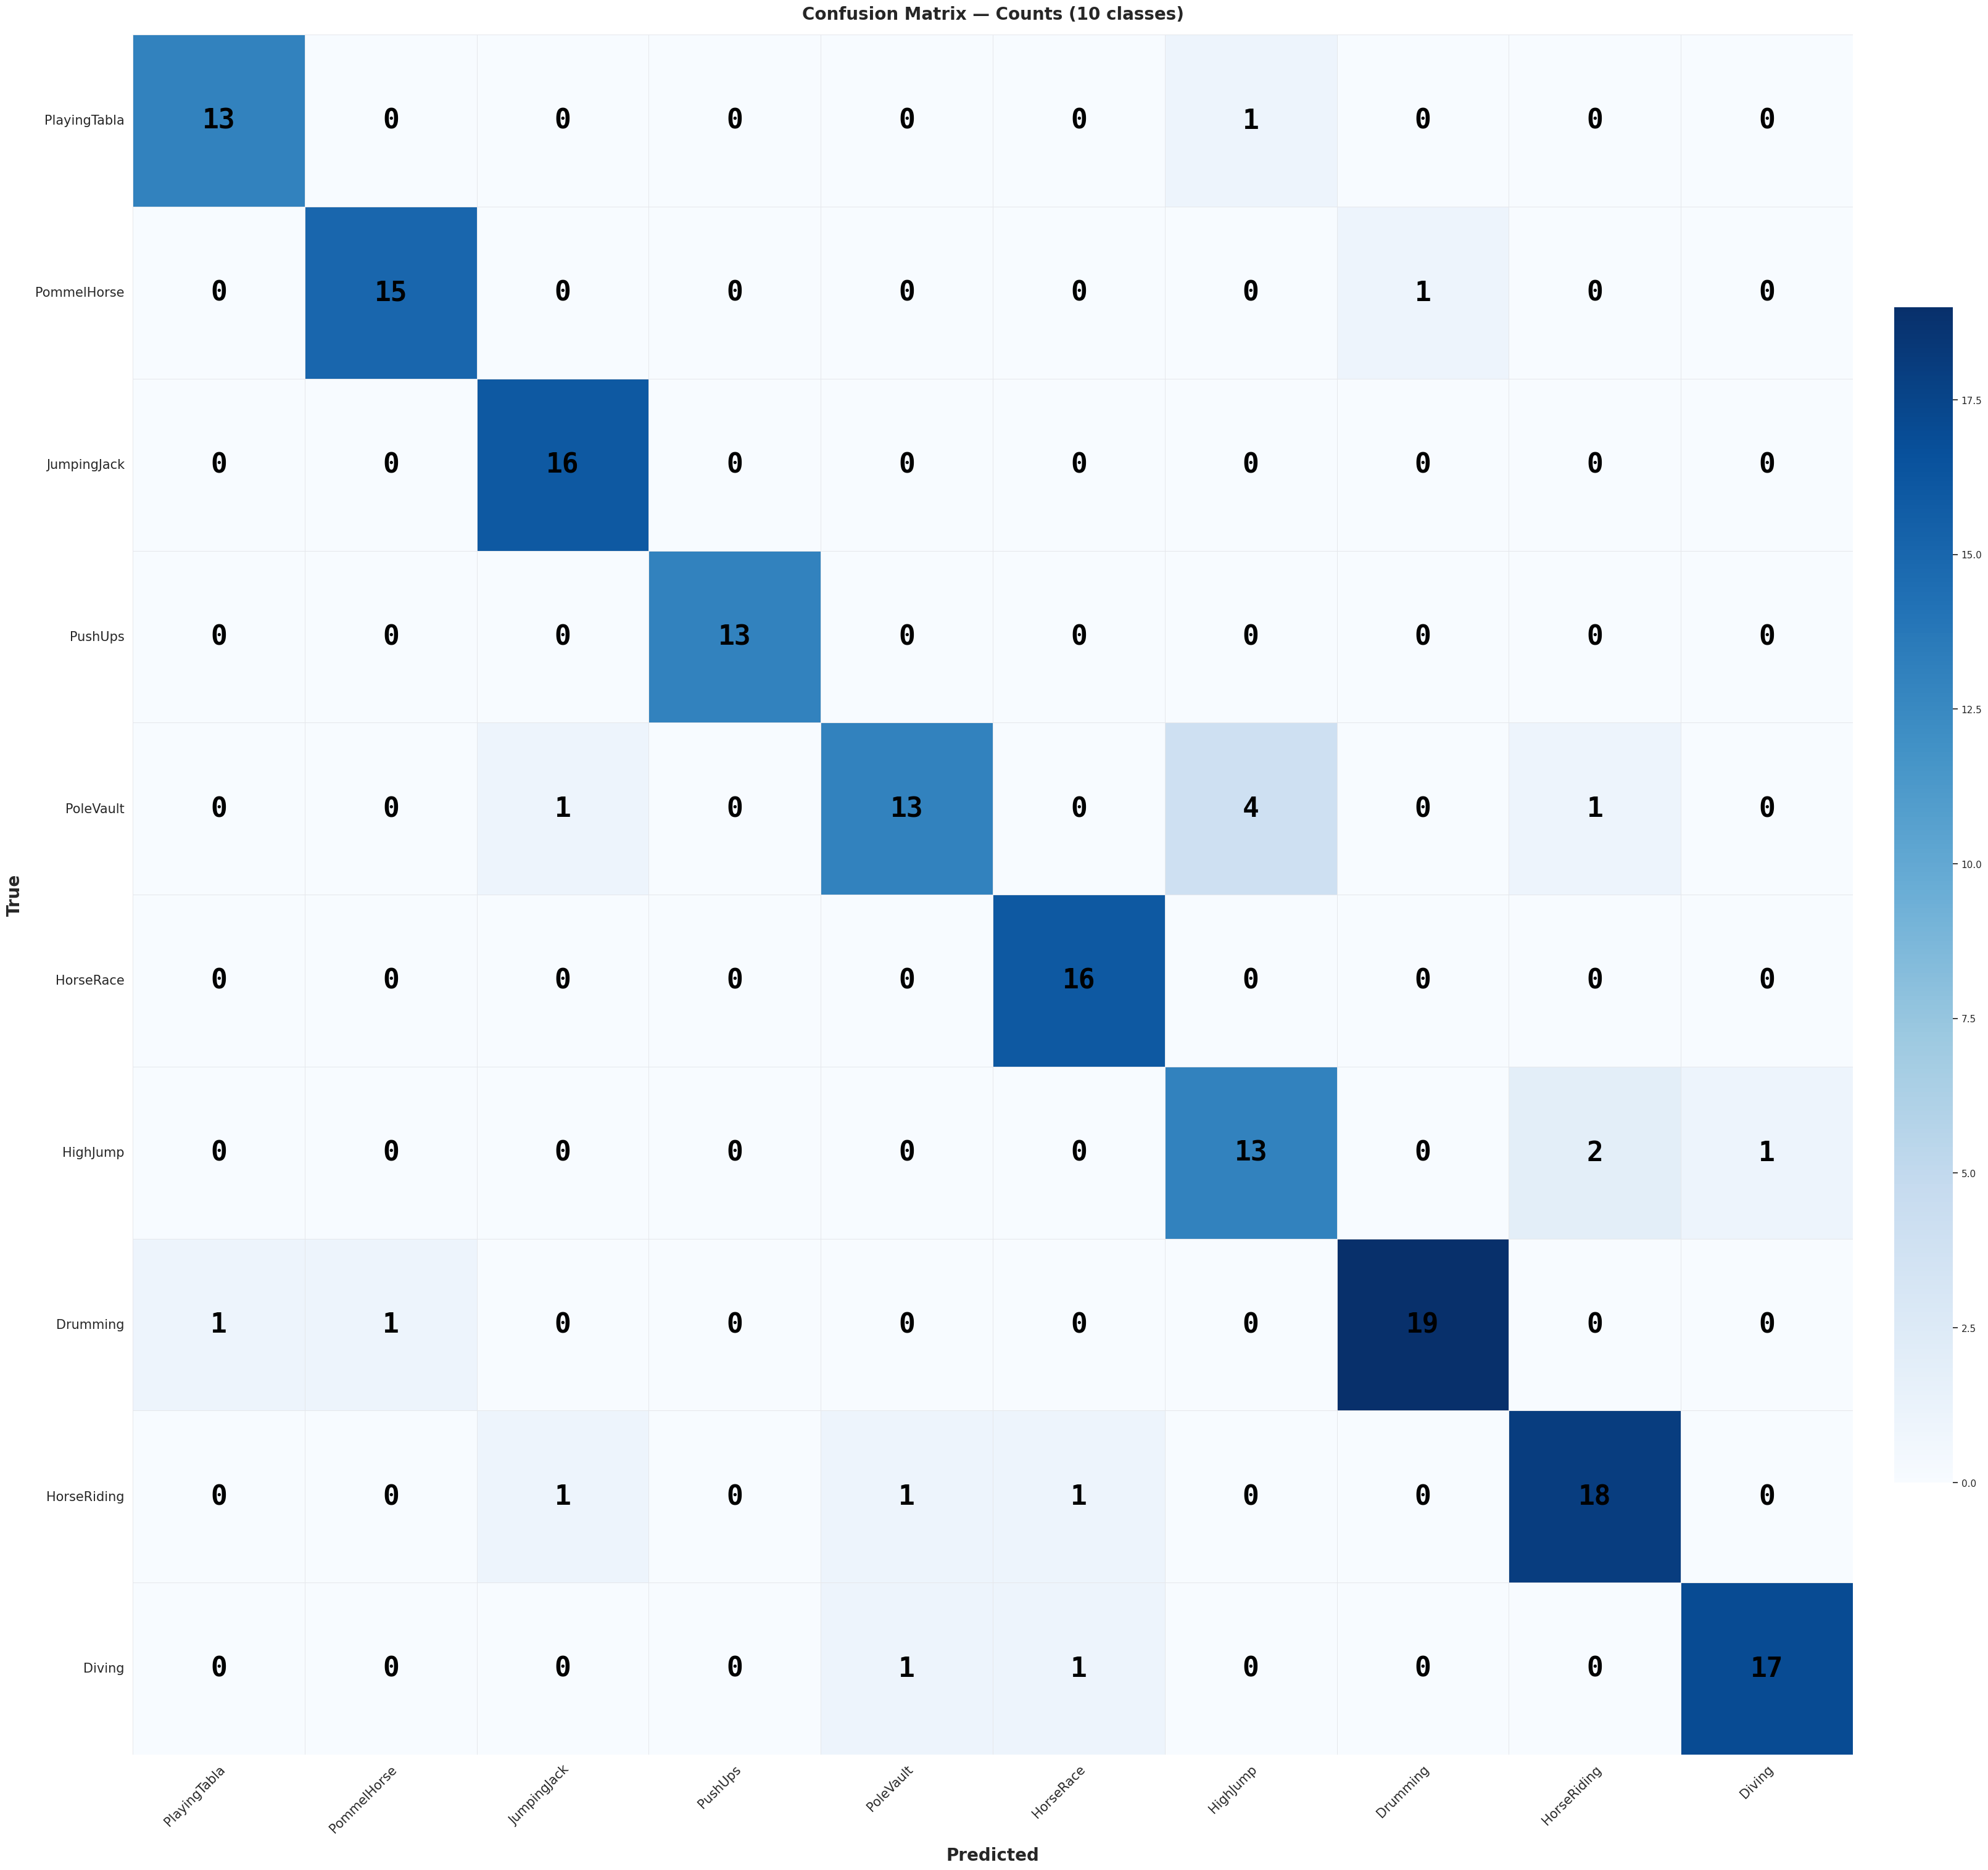

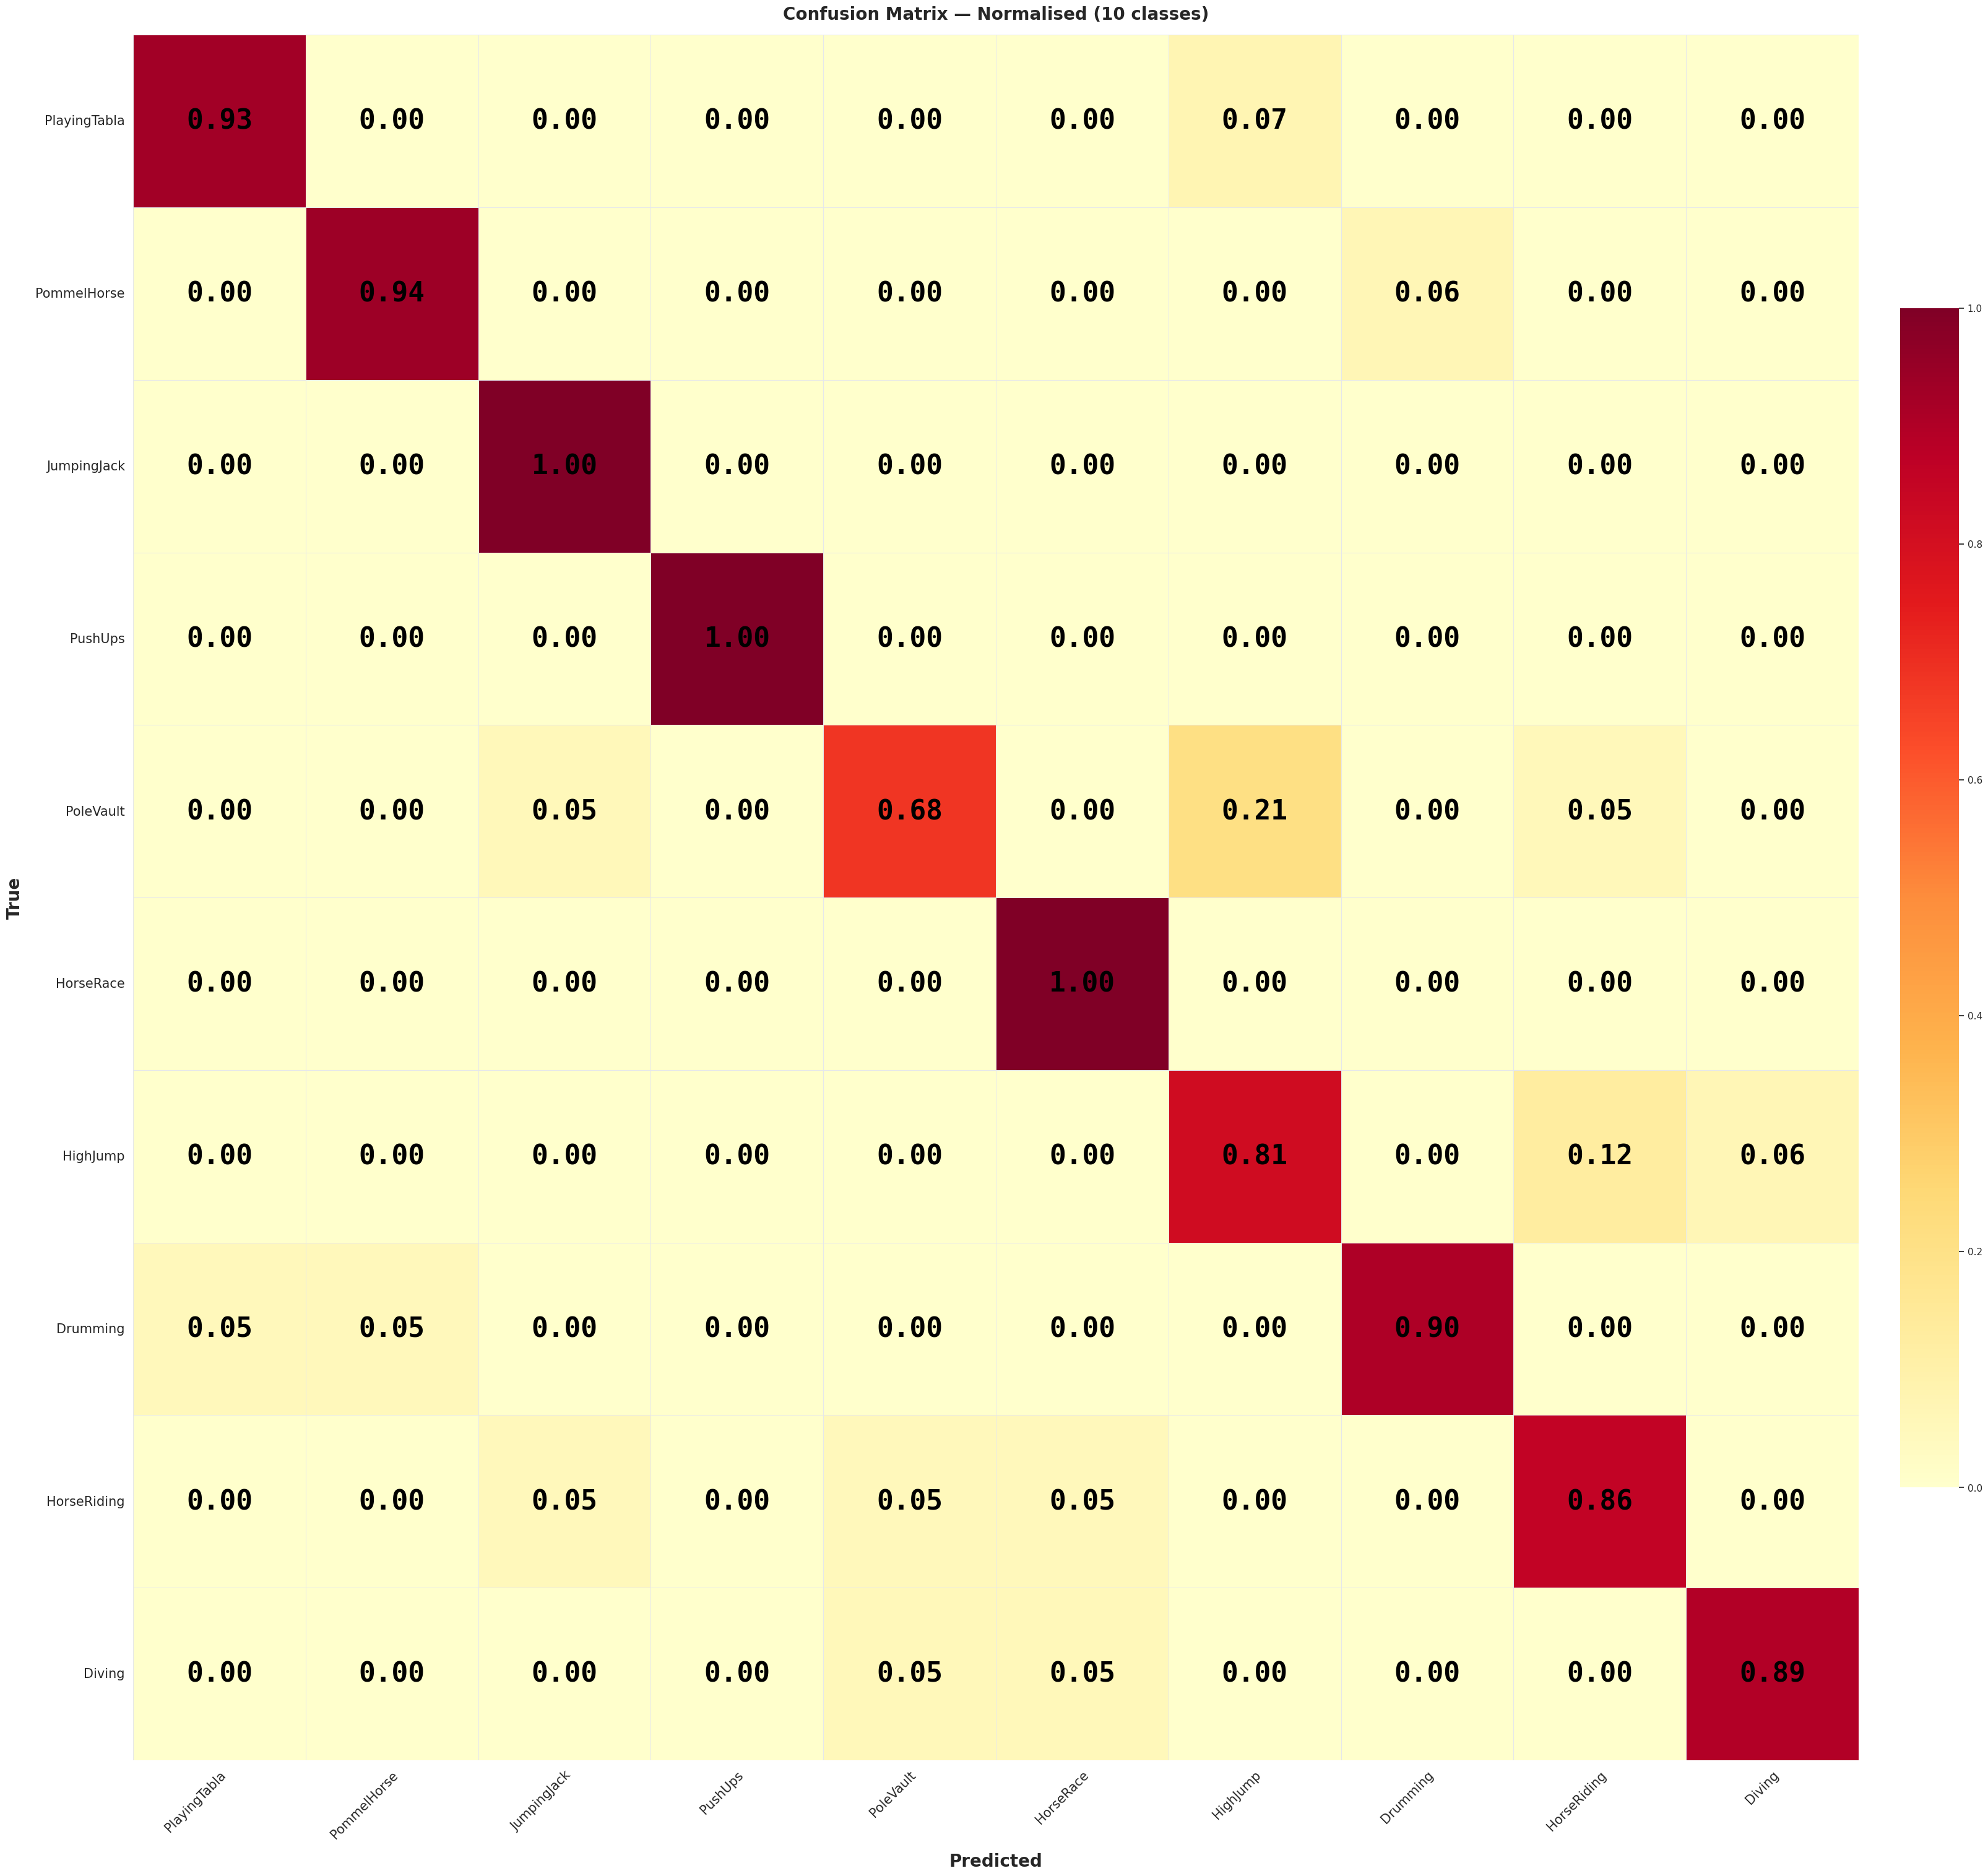

In [13]:
# plot cm
plot_confusion_matrix(all_labels_cust_cnn, all_preds_cust_cnn, num_classes=10, classes_list=SELECTED_CLASSES)

## **RESNET18 + LSTM**

In [14]:
# Instantiate the model (pre-trained)
resnet_18 = ResNet18LSTM()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s]


In [15]:
# Inspect model's architecture
summary(resnet_18, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet18LSTM                                  [1, 10]                   --
├─Sequential: 1-1                             [16, 512, 1, 1]           --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 64, 56, 56]          --
│    │    └─BasicBlock: 3-1                   [16, 64, 56, 56]          (73,984)
│    │    └─BasicBlock: 3-2                   [16, 64, 56, 56]          (73,984)
│    └─Sequential: 2-6                        [16, 128, 28, 28]         --
│    │    └─BasicBlock: 3-3                   [16, 128, 28, 28]         (230,144)
│    │    └─BasicBlock: 3-4                   [16, 128, 28, 28]     

In [17]:
results_resnet_18 = train_model(
    resnet_18,
    train_loader_10,
    val_loader_10,
    num_epochs=5
)

Epoch [1/5] | Train Acc: 0.9628 Loss: 0.1617 | Val Acc: 0.9697 Loss: 0.1147


Epoch [2/5] | Train Acc: 0.9849 Loss: 0.0755 | Val Acc: 0.9818 Loss: 0.0981


Epoch [3/5] | Train Acc: 0.9899 Loss: 0.0601 | Val Acc: 0.9818 Loss: 0.0956


Epoch [4/5] | Train Acc: 0.9869 Loss: 0.0603 | Val Acc: 0.9576 Loss: 0.1269


Epoch [5/5] | Train Acc: 0.9960 Loss: 0.0343 | Val Acc: 0.9455 Loss: 0.1548


In [18]:
# test the model
test_acc_resnet_18, all_preds_resnet_18, all_labels_resnet_18 = test_model(resnet_18, test_loader_10)

Running Inference on Test Set...


Test Accuracy: 0.9708


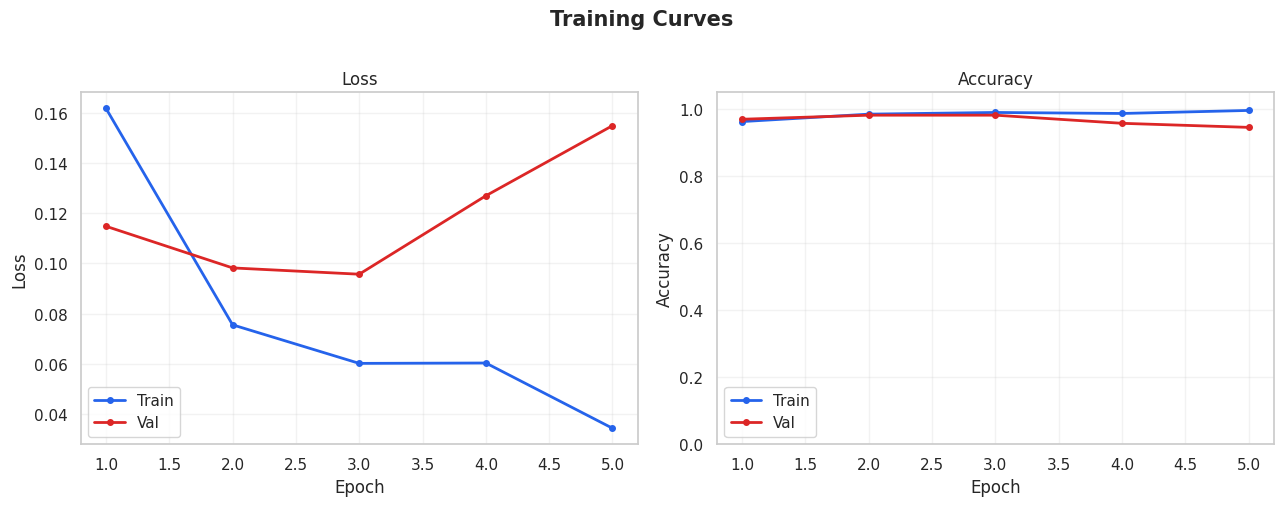

In [19]:
# plot results
plot_training_results(results_resnet_18)

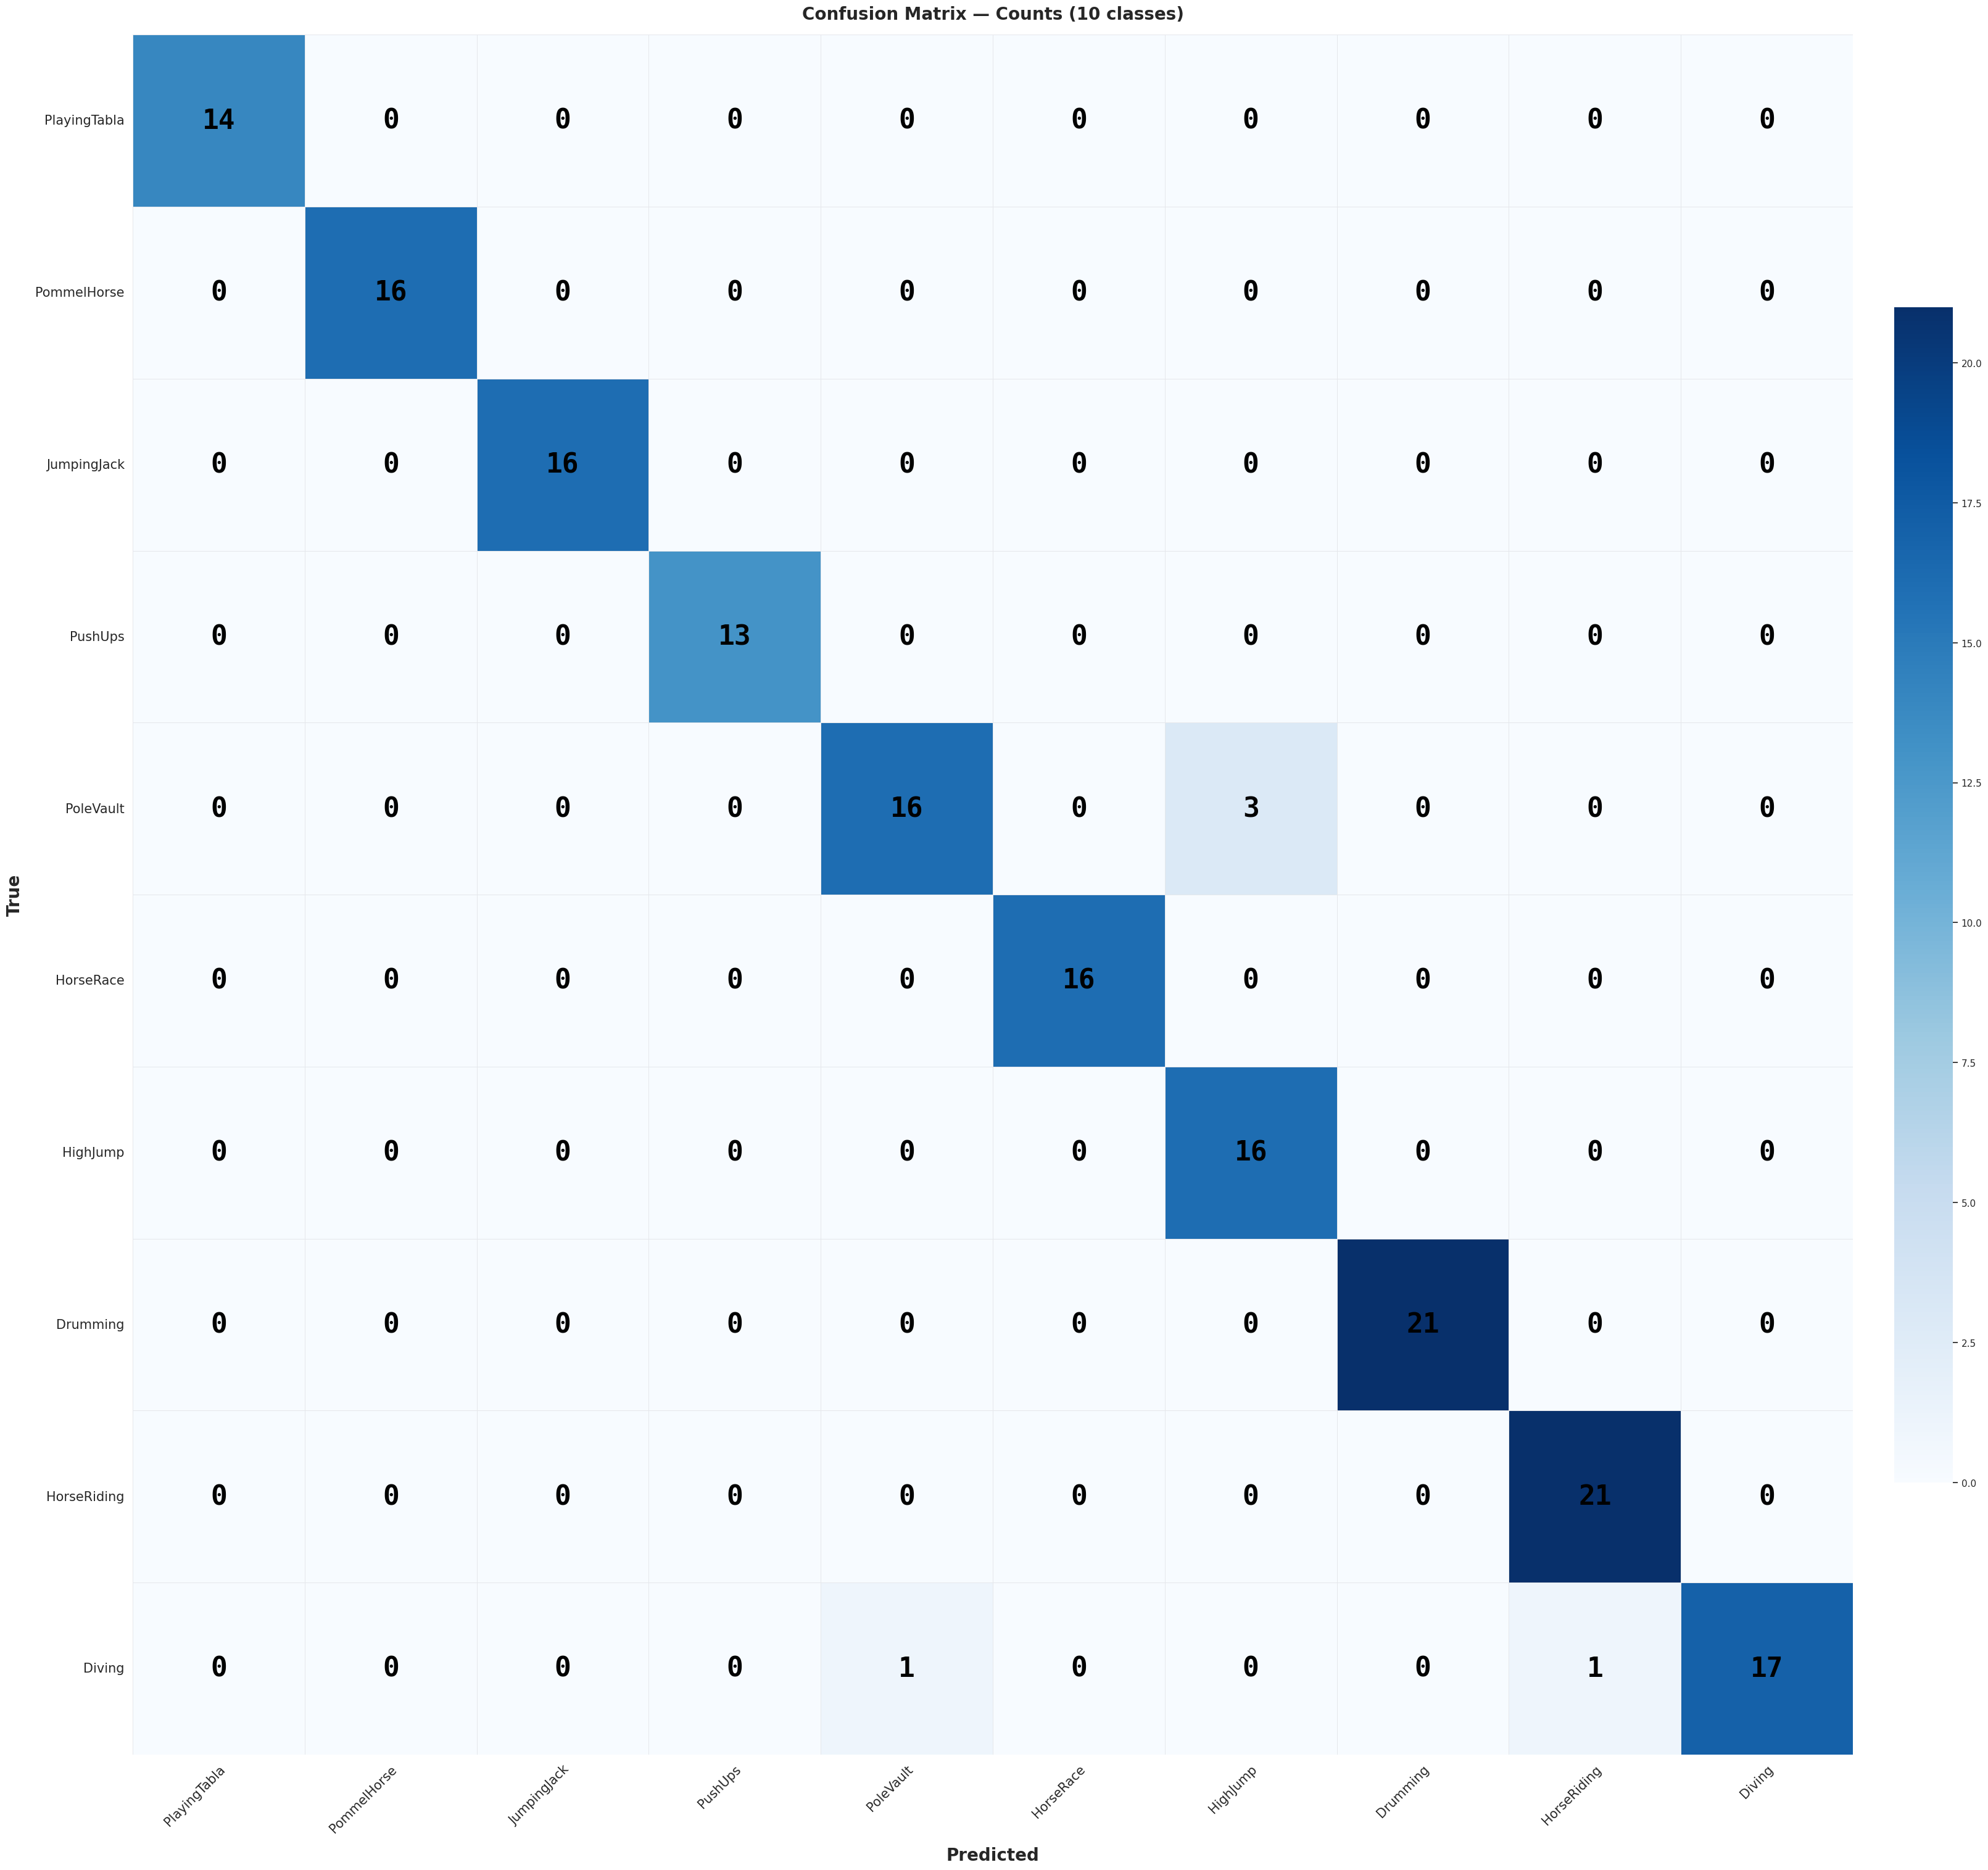

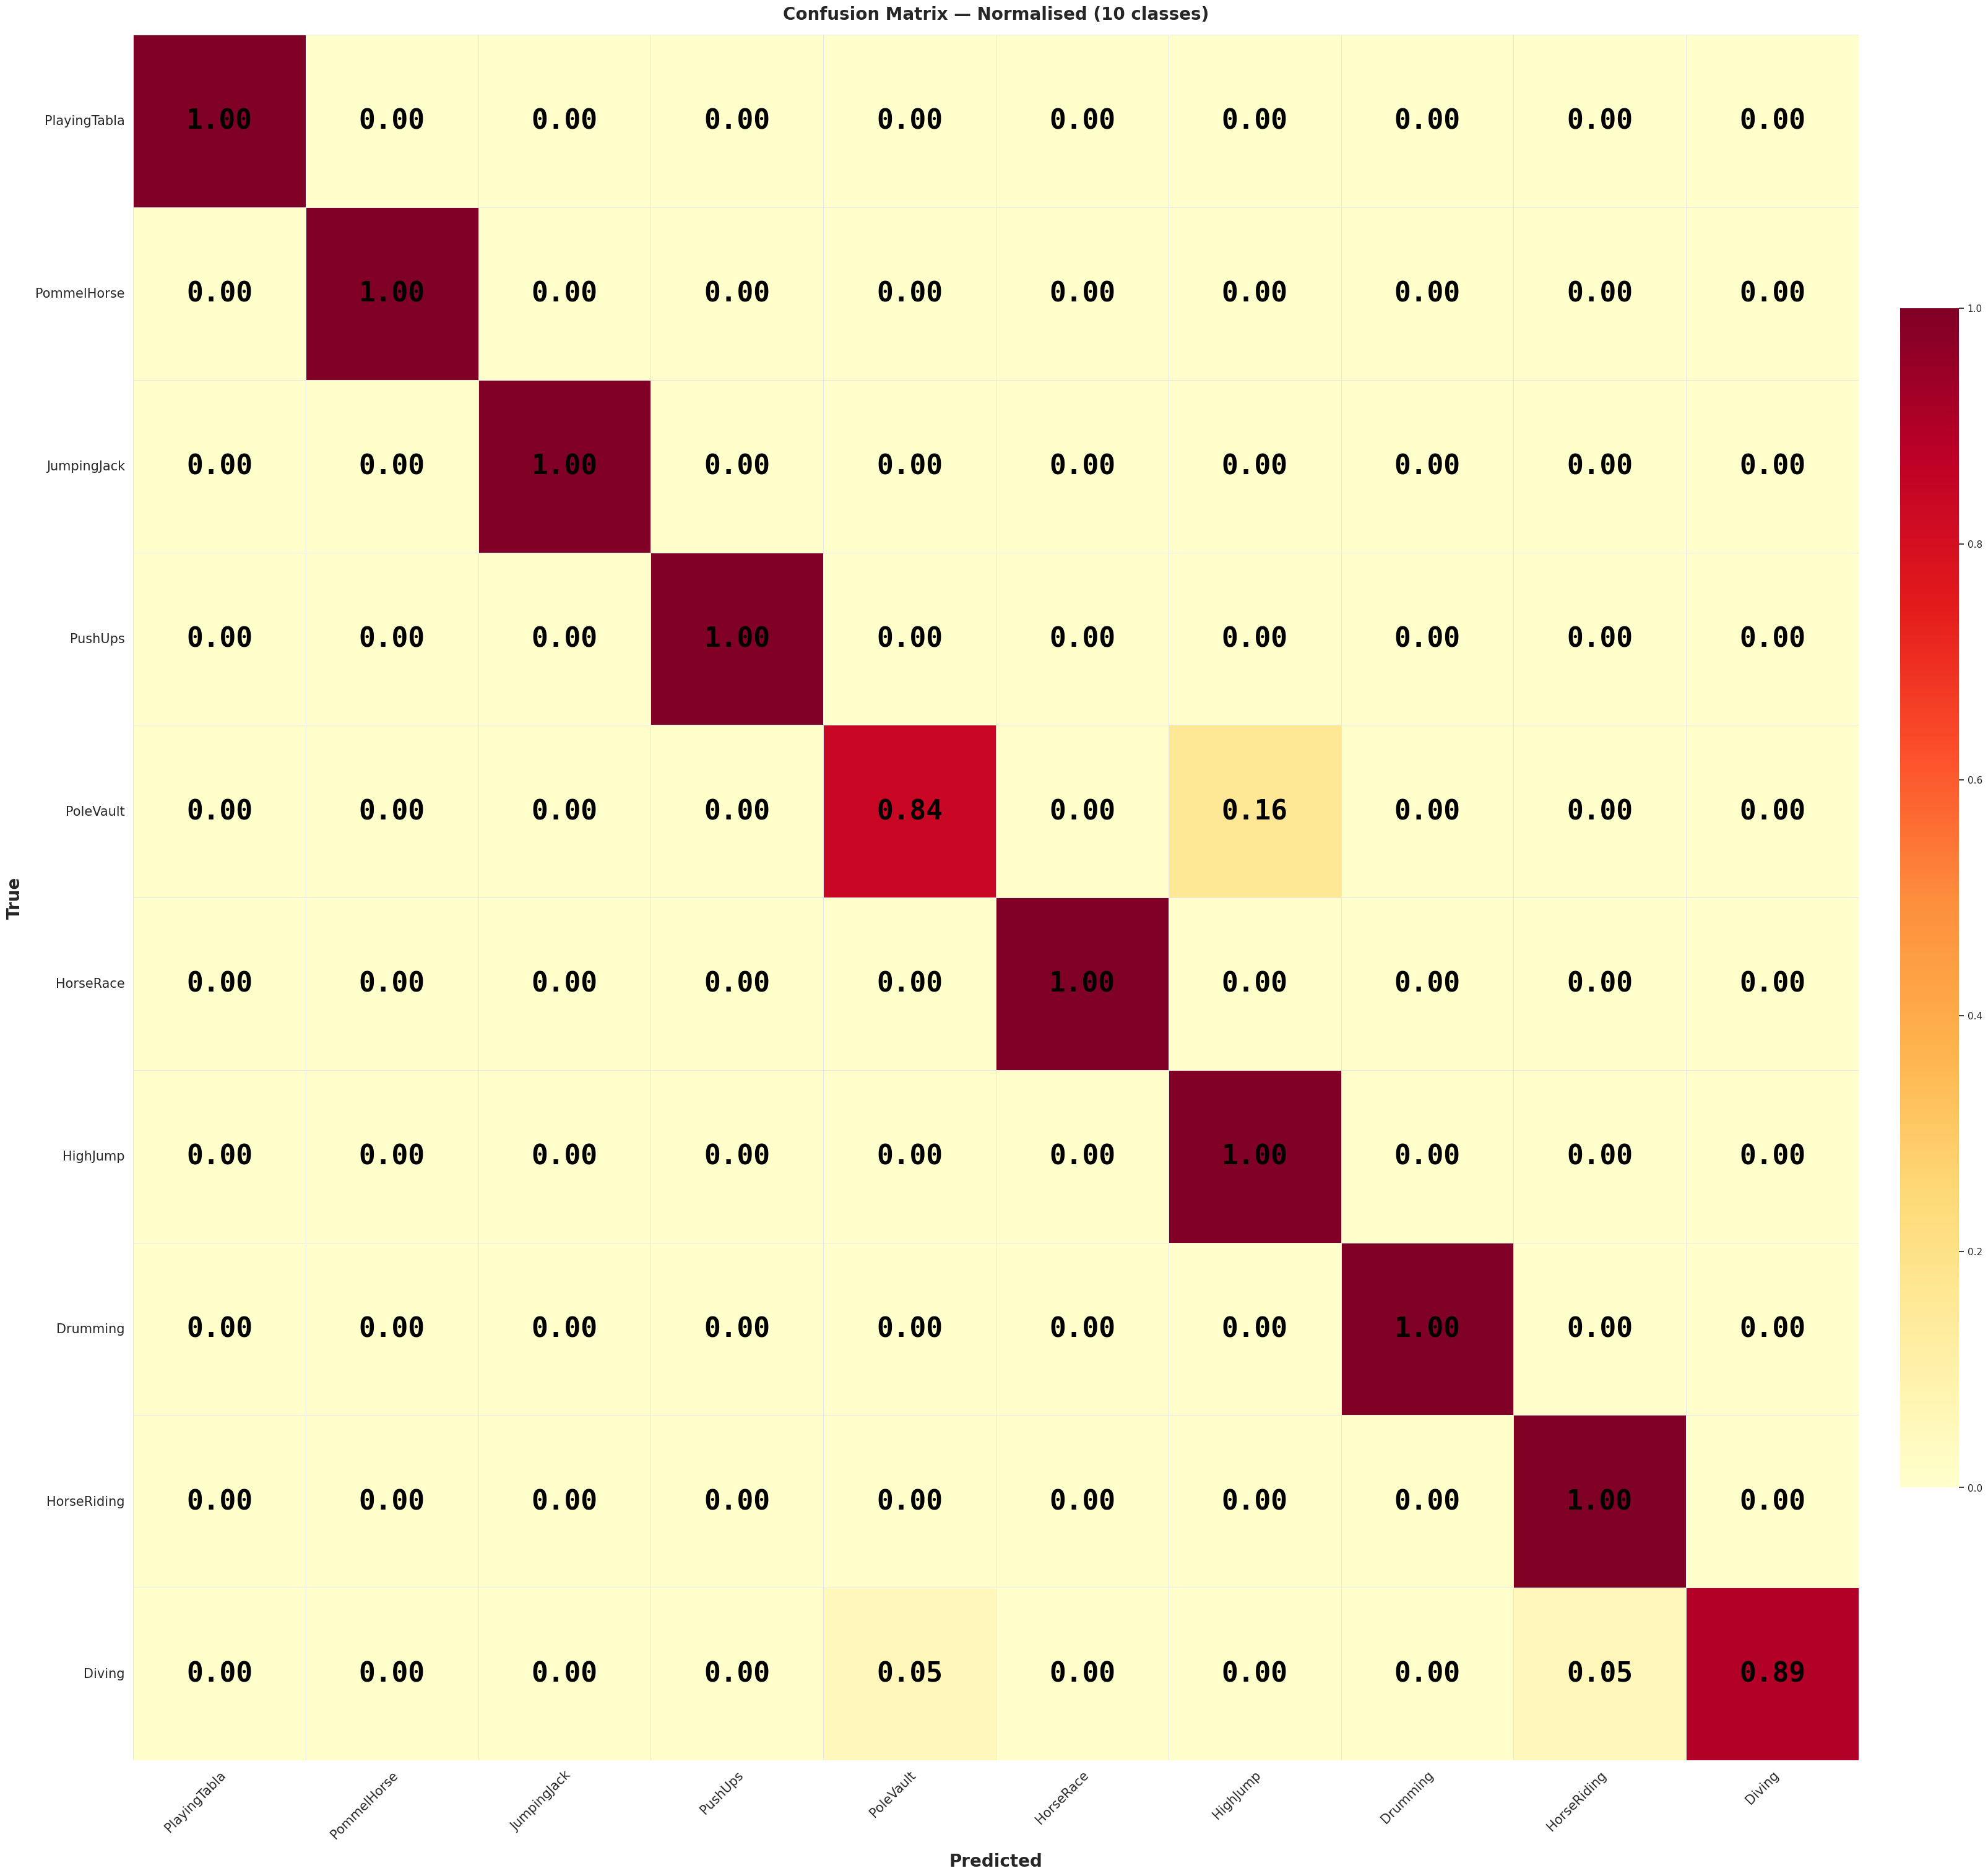

In [21]:
# plot cm
plot_confusion_matrix(all_labels_resnet_18, all_preds_resnet_18, num_classes=10, classes_list=SELECTED_CLASSES)

In [23]:
# print detailed metrics
print_detailed_metrics(all_labels_resnet_18, all_preds_resnet_18, num_classes=10, classes_list=SELECTED_CLASSES)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9708
  Precision : 0.9731
  Recall    : 0.9708
  F1-Score  : 0.9706

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        14
 PommelHorse       1.00      1.00      1.00        16
 JumpingJack       1.00      1.00      1.00        16
     PushUps       1.00      1.00      1.00        13
   PoleVault       0.94      0.84      0.89        19
   HorseRace       1.00      1.00      1.00        16
    HighJump       0.84      1.00      0.91        16
    Drumming       1.00      1.00      1.00        21
 HorseRiding       0.95      1.00      0.98        21
      Diving       1.00      0.89      0.94        19

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

TOP 5 BEST CLASSES (F1)
  1. HorseRace                : 1.0000
  2. Drumming           

## **RESNET50 + LSTM**

In [24]:
model_ResNet50 = ResNet50LSTM()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


In [25]:
summary(model_ResNet50, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet50LSTM                                  [1, 10]                   --
├─Sequential: 1-1                             [16, 2048, 1, 1]          --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 256, 56, 56]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 56, 56]         (75,008)
│    │    └─Bottleneck: 3-2                   [16, 256, 56, 56]         (70,400)
│    │    └─Bottleneck: 3-3                   [16, 256, 56, 56]         (70,400)
│    └─Sequential: 2-6                        [16, 512, 28, 28]         --
│    │    └─Bottleneck: 3-4                   [16, 512, 28, 28]      

#### **New folders on drive**

In [26]:
# path
base_path = '/content/drive/MyDrive/apai/resnet50'

# folders
folders = ['models', 'features']

# create folders
for folder in folders:
    path = os.path.join(base_path, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/apai/resnet50/models
Created: /content/drive/MyDrive/apai/resnet50/features


In [27]:
# fine tune
results_resnet_50 = train_model(
    model_ResNet50,
    train_loader_10,
    val_loader_10,
    num_epochs=5,
    save_path='/content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth'
)

Epoch [1/5] | Train Acc: 0.6459 Loss: 1.3540 | Val Acc: 0.9152 Loss: 0.3867
  --> Model saved to /content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth


Epoch [2/5] | Train Acc: 0.9185 Loss: 0.3237 | Val Acc: 0.9818 Loss: 0.1547
  --> Model saved to /content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth


Epoch [3/5] | Train Acc: 0.9668 Loss: 0.1452 | Val Acc: 0.9758 Loss: 0.1217


Epoch [4/5] | Train Acc: 0.9799 Loss: 0.0876 | Val Acc: 0.9758 Loss: 0.1228


Epoch [5/5] | Train Acc: 0.9920 Loss: 0.0519 | Val Acc: 0.9758 Loss: 0.1114


### **UPLOAD BEST SAVED**

In [28]:
model_path = '/content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth'

# model for feature extraction
model_ResNet50 = ResNet50LSTM(hidden_size=256, num_classes=10).to(device)
checkpoint = torch.load(model_path, map_location=device)
model_ResNet50.load_state_dict(checkpoint)

<All keys matched successfully>

In [29]:
# test the model
test_acc_results_resnet_50, all_preds_results_resnet_50, all_labels_results_resnet_50 = test_model(model_ResNet50, test_loader_10, device=device)

Running Inference on Test Set...


Test Accuracy: 0.9825


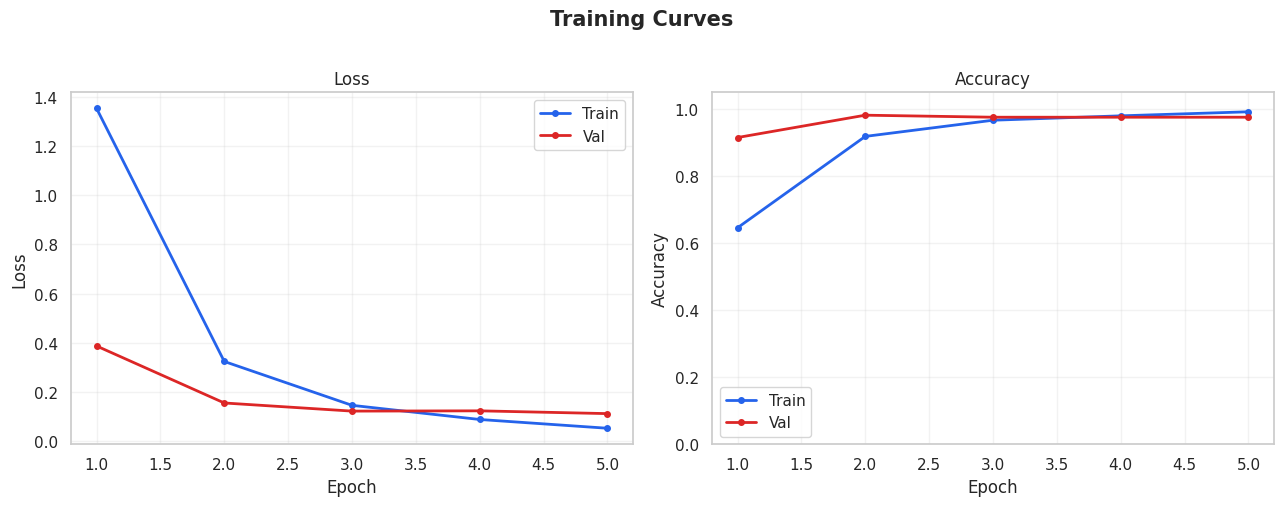

In [30]:
# plot results
plot_training_results(results_resnet_50)

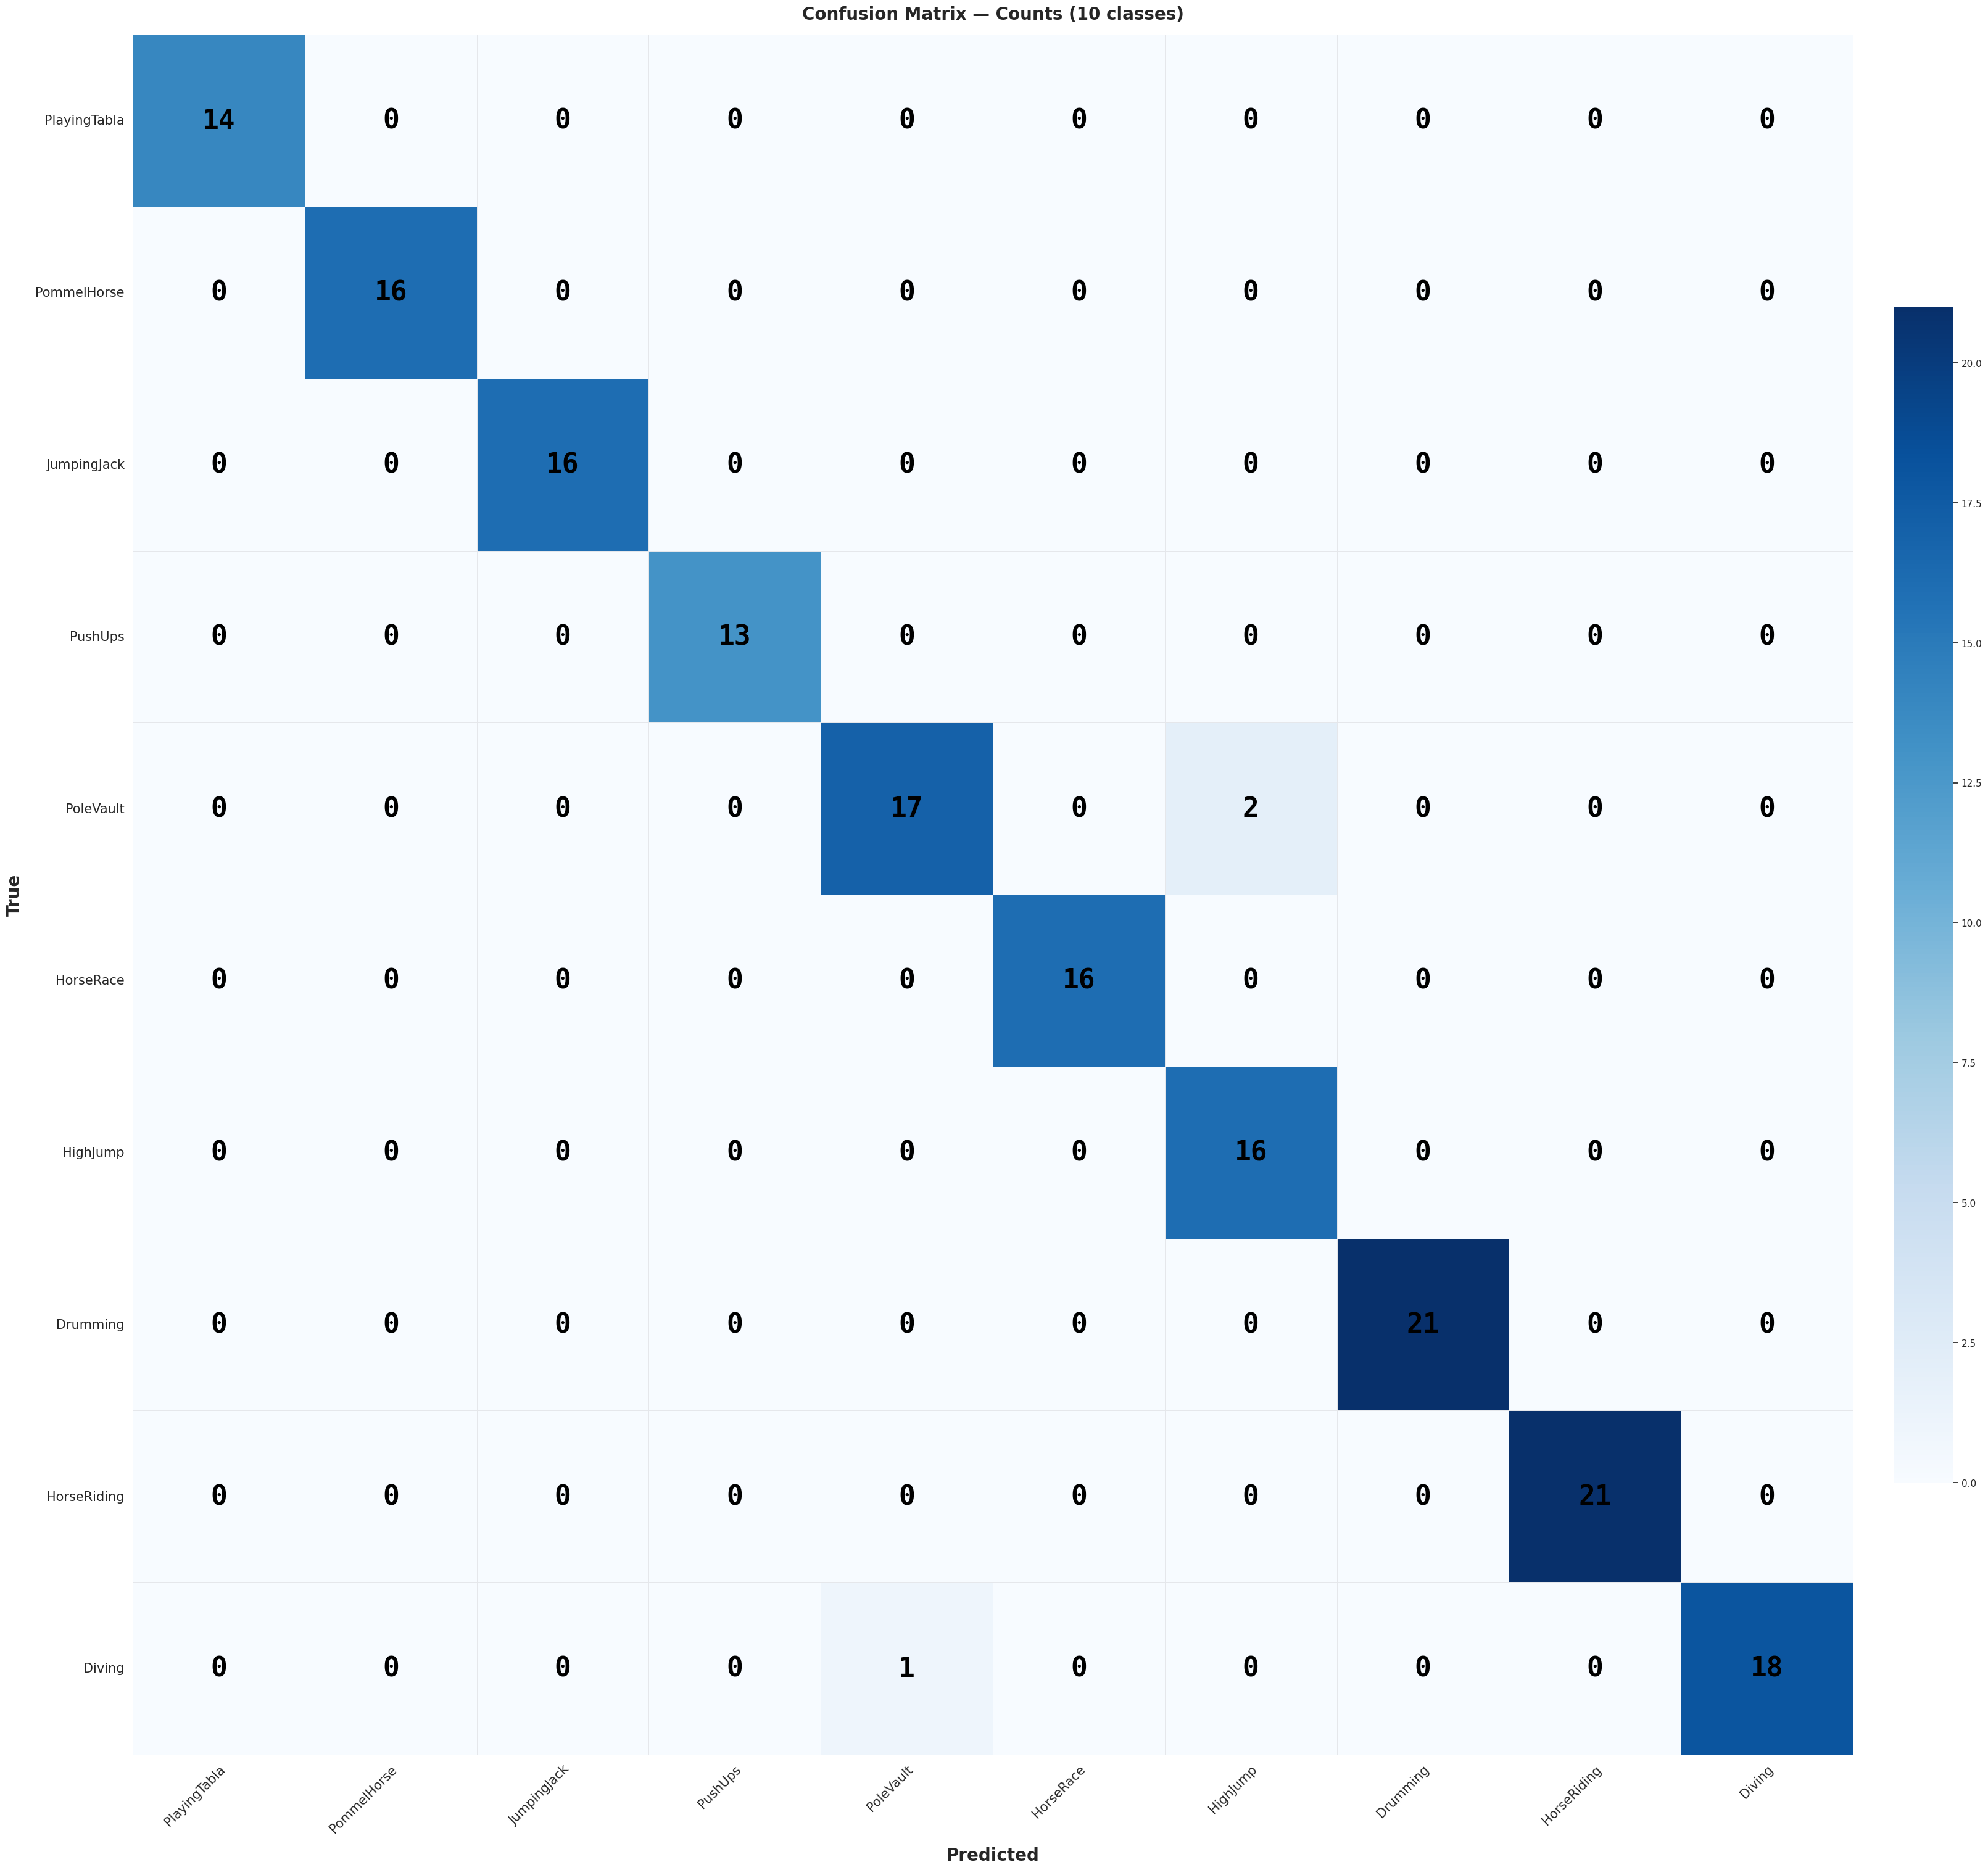

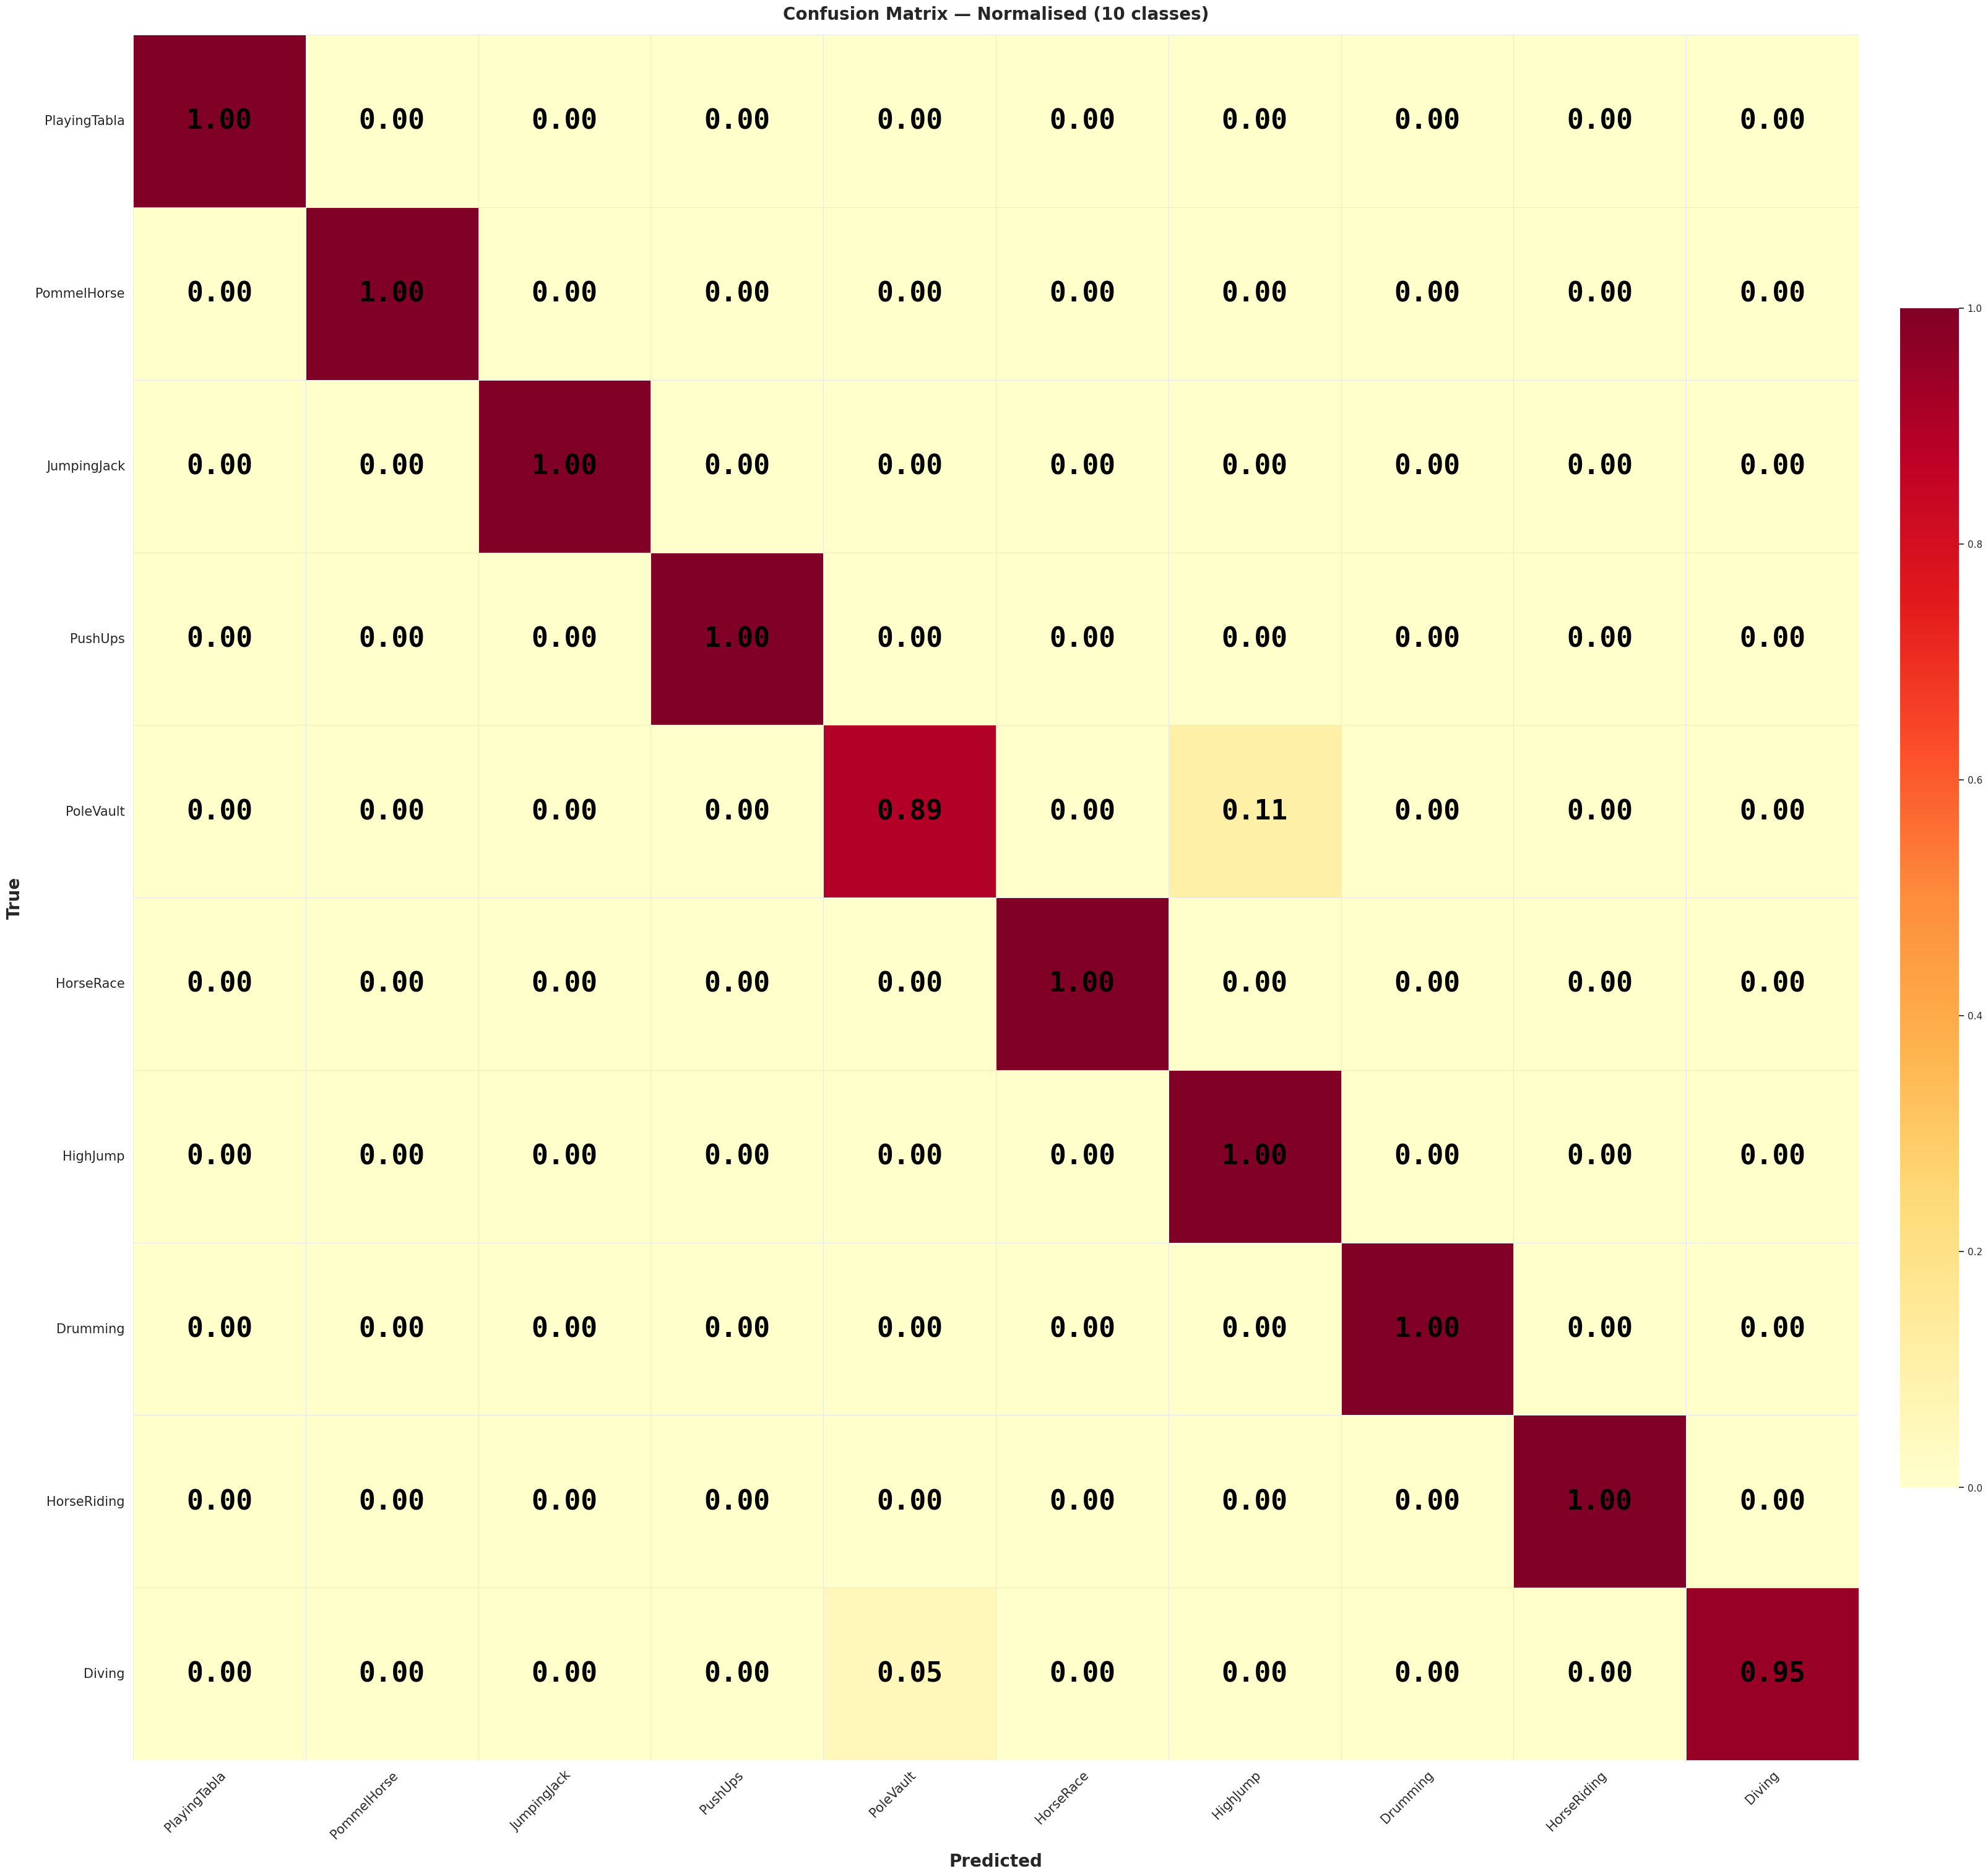

In [31]:
# plot cm
plot_confusion_matrix(all_labels_results_resnet_50, all_preds_results_resnet_50, num_classes=10, classes_list=SELECTED_CLASSES)

In [32]:
# print detailed metrics
print_detailed_metrics(all_labels_results_resnet_50, all_preds_results_resnet_50, num_classes=10, classes_list=SELECTED_CLASSES)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9825
  Precision : 0.9834
  Recall    : 0.9825
  F1-Score  : 0.9825

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        14
 PommelHorse       1.00      1.00      1.00        16
 JumpingJack       1.00      1.00      1.00        16
     PushUps       1.00      1.00      1.00        13
   PoleVault       0.94      0.89      0.92        19
   HorseRace       1.00      1.00      1.00        16
    HighJump       0.89      1.00      0.94        16
    Drumming       1.00      1.00      1.00        21
 HorseRiding       1.00      1.00      1.00        21
      Diving       1.00      0.95      0.97        19

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171

TOP 5 BEST CLASSES (F1)
  1. HorseRiding              : 1.0000
  2. Drumming           

## **DenseNet121 + LSTM**

In [33]:
densenet_121 = DenseNet121LSTM()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 198MB/s]


In [34]:
summary(densenet_121, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet121LSTM                          [1, 10]                   --
├─Sequential: 1-1                        [16, 1024, 7, 7]          --
│    └─Conv2d: 2-1                       [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                  [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                         [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [16, 64, 56, 56]          --
│    └─_DenseBlock: 2-5                  [16, 256, 56, 56]         --
│    │    └─_DenseLayer: 3-1             [16, 32, 56, 56]          (45,440)
│    │    └─_DenseLayer: 3-2             [16, 32, 56, 56]          (49,600)
│    │    └─_DenseLayer: 3-3             [16, 32, 56, 56]          (53,760)
│    │    └─_DenseLayer: 3-4             [16, 32, 56, 56]          (57,920)
│    │    └─_DenseLayer: 3-5             [16, 32, 56, 56]          (62,080)
│    │    └─_DenseLayer: 3-6             [16, 3

In [35]:
results_densenet_121 = train_model(
    densenet_121,
    train_loader_10,
    val_loader_10,
    num_epochs=5
)

Epoch [1/5] | Train Acc: 0.6700 Loss: 1.4144 | Val Acc: 0.8909 Loss: 0.5766


Epoch [2/5] | Train Acc: 0.9245 Loss: 0.3670 | Val Acc: 0.9515 Loss: 0.1938


Epoch [3/5] | Train Acc: 0.9748 Loss: 0.1369 | Val Acc: 0.9758 Loss: 0.1171


Epoch [4/5] | Train Acc: 0.9859 Loss: 0.0768 | Val Acc: 0.9939 Loss: 0.0845


Epoch [5/5] | Train Acc: 0.9869 Loss: 0.0609 | Val Acc: 0.9879 Loss: 0.0762


In [36]:
# test the model
test_acc_densenet_121, all_preds_densenet_121, all_labels_densenet_121 = test_model(densenet_121, test_loader_10, device=device)

Running Inference on Test Set...


Test Accuracy: 0.9883


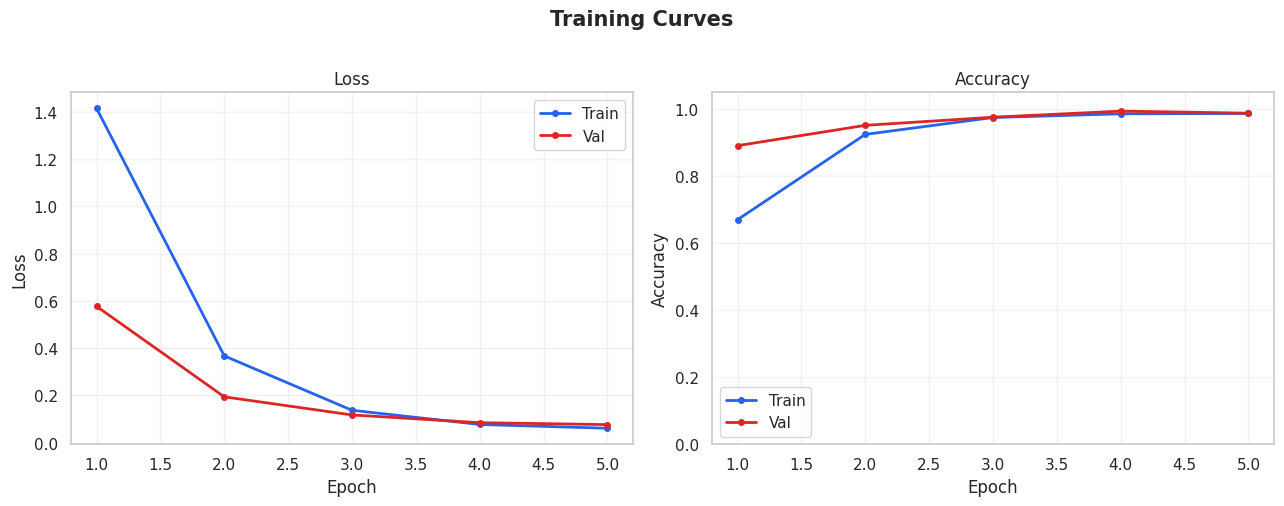

In [37]:
# plot results
plot_training_results(results_densenet_121)

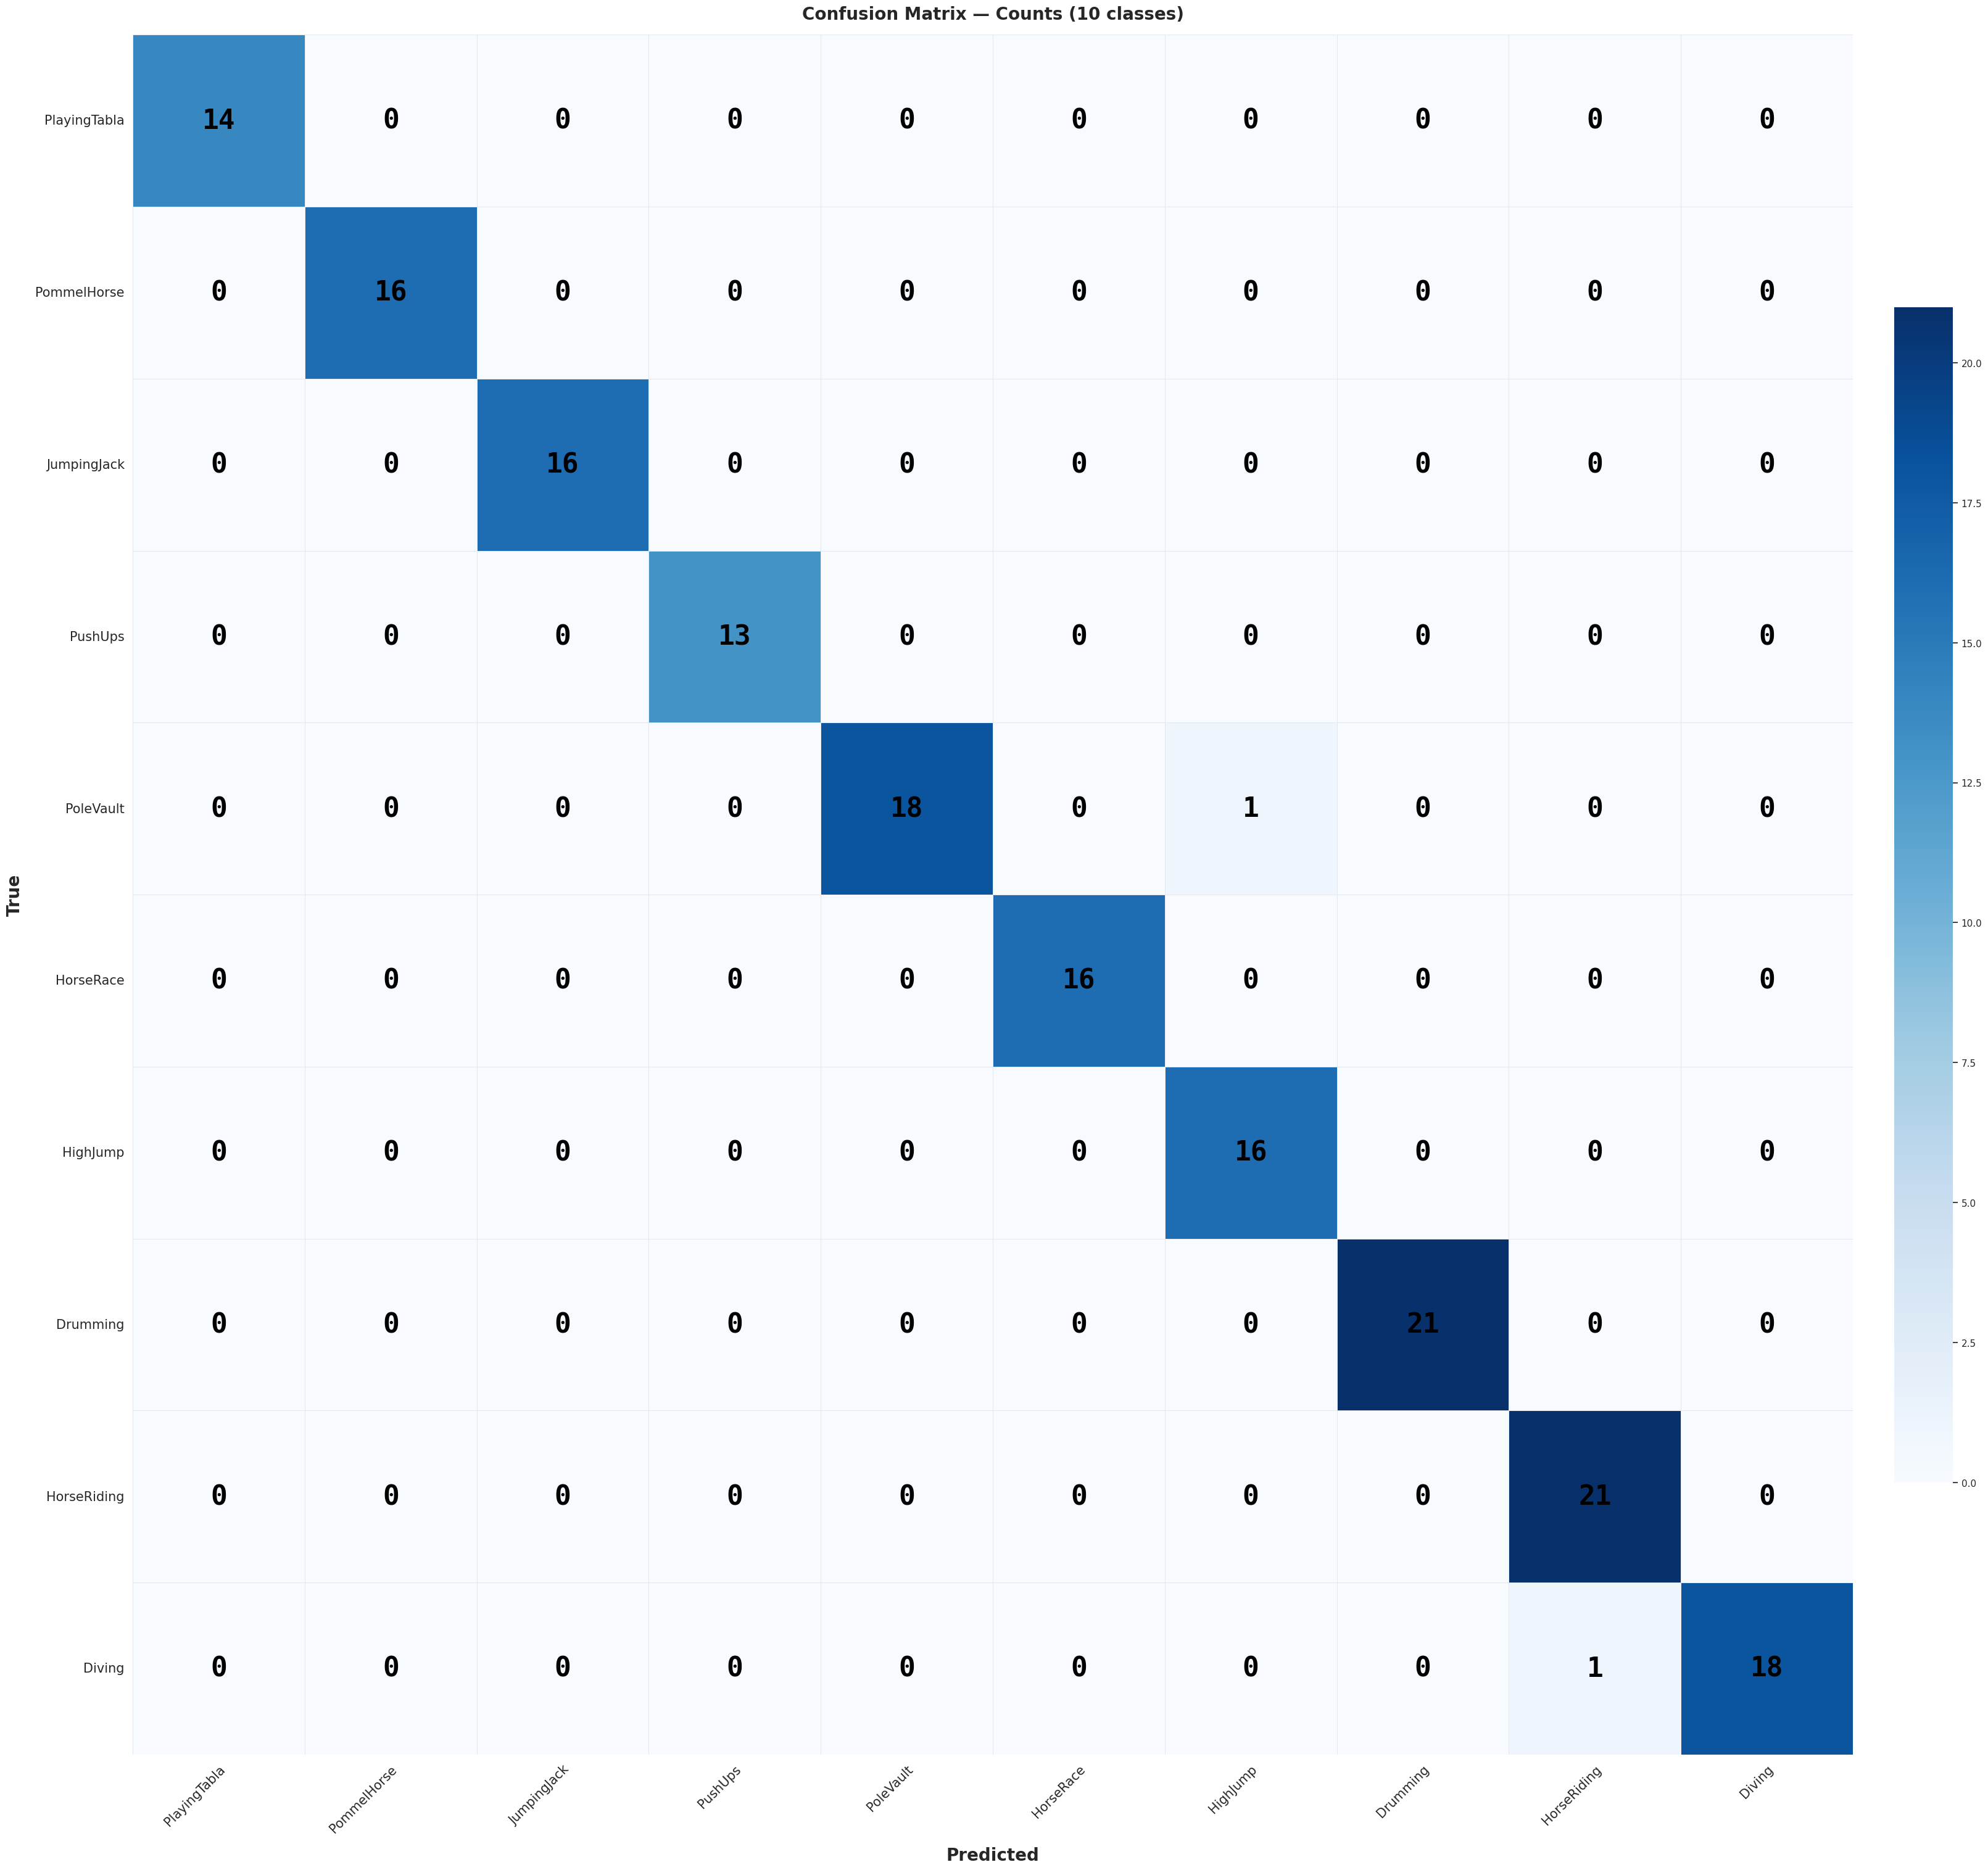

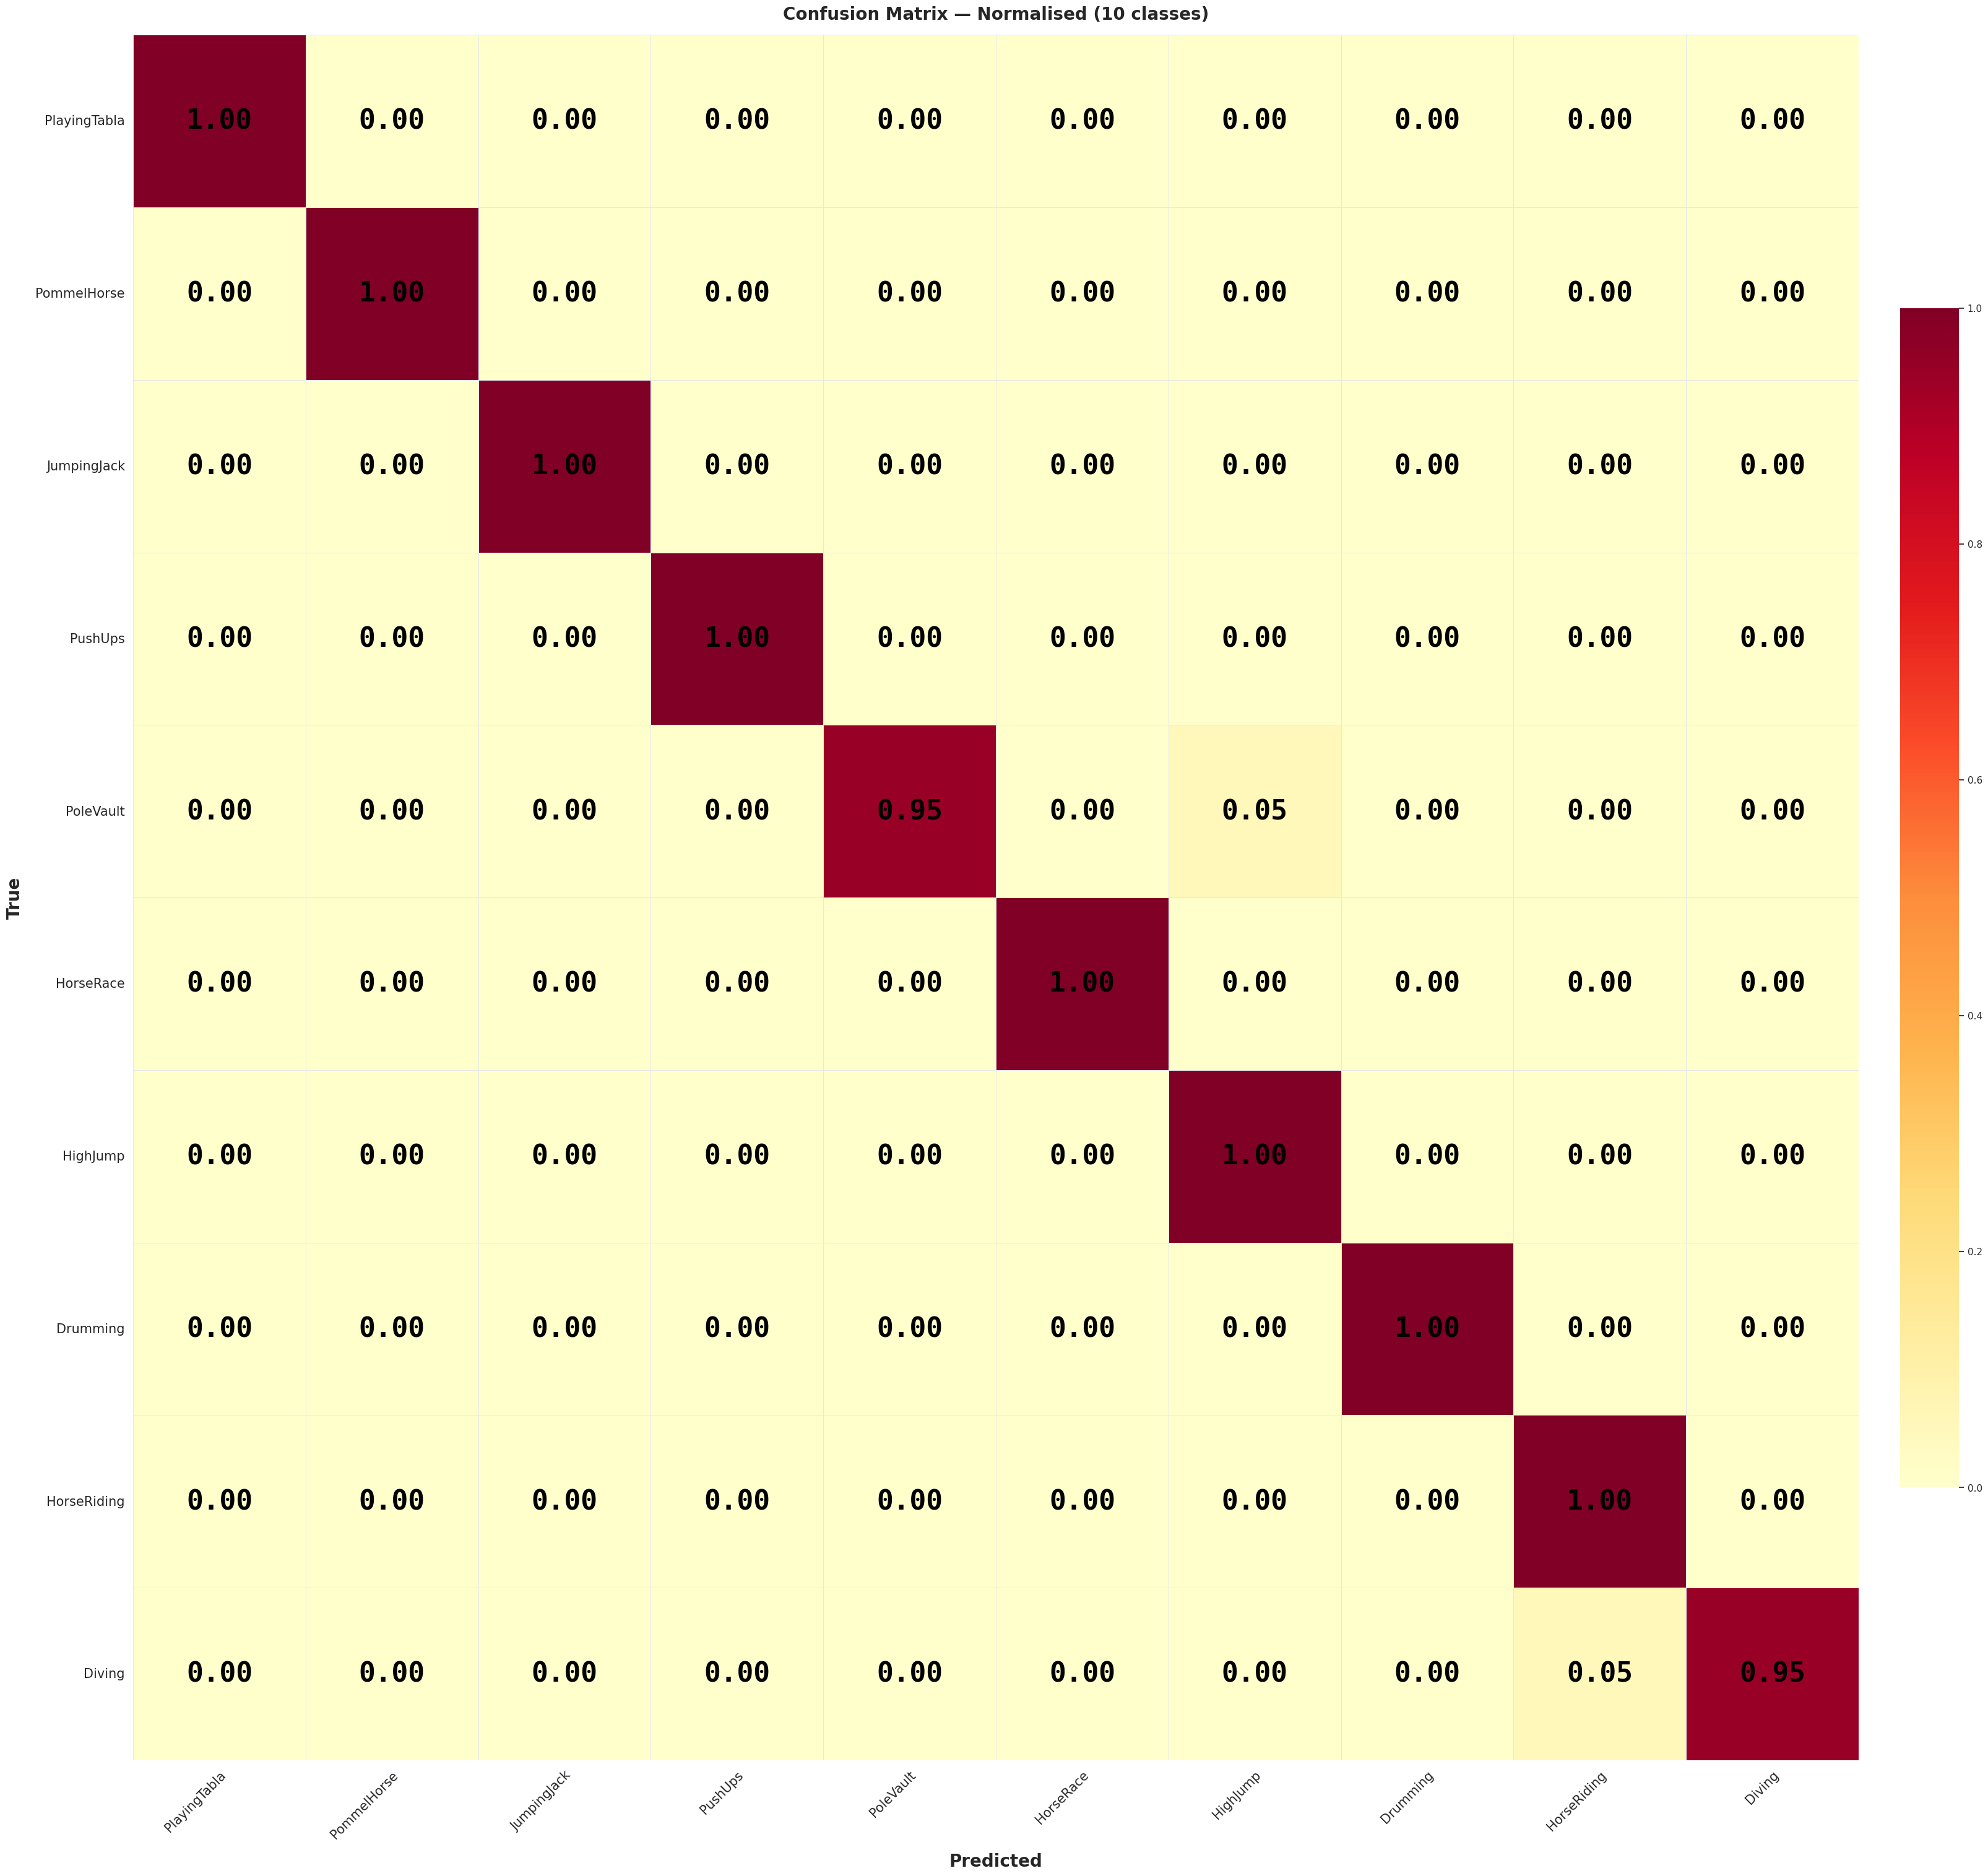

In [38]:
plot_confusion_matrix(all_labels_densenet_121, all_preds_densenet_121, num_classes=10, classes_list=SELECTED_CLASSES)

In [39]:
# print detailed metrics
print_detailed_metrics(all_labels_densenet_121, all_preds_densenet_121, num_classes=10, classes_list=SELECTED_CLASSES)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9883
  Precision : 0.9889
  Recall    : 0.9883
  F1-Score  : 0.9883

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        14
 PommelHorse       1.00      1.00      1.00        16
 JumpingJack       1.00      1.00      1.00        16
     PushUps       1.00      1.00      1.00        13
   PoleVault       1.00      0.95      0.97        19
   HorseRace       1.00      1.00      1.00        16
    HighJump       0.94      1.00      0.97        16
    Drumming       1.00      1.00      1.00        21
 HorseRiding       0.95      1.00      0.98        21
      Diving       1.00      0.95      0.97        19

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171

TOP 5 BEST CLASSES (F1)
  1. HorseRace                : 1.0000
  2. Drumming           

## **VGG19_BN + LSTM**

In [40]:
vgg_19 = VGG19BNLSTM()

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:08<00:00, 66.7MB/s] 


In [41]:
summary(vgg_19, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG19BNLSTM                              [1, 10]                   --
├─Sequential: 1-1                        [16, 512, 7, 7]           --
│    └─Conv2d: 2-1                       [16, 64, 224, 224]        (1,792)
│    └─BatchNorm2d: 2-2                  [16, 64, 224, 224]        (128)
│    └─ReLU: 2-3                         [16, 64, 224, 224]        --
│    └─Conv2d: 2-4                       [16, 64, 224, 224]        (36,928)
│    └─BatchNorm2d: 2-5                  [16, 64, 224, 224]        (128)
│    └─ReLU: 2-6                         [16, 64, 224, 224]        --
│    └─MaxPool2d: 2-7                    [16, 64, 112, 112]        --
│    └─Conv2d: 2-8                       [16, 128, 112, 112]       (73,856)
│    └─BatchNorm2d: 2-9                  [16, 128, 112, 112]       (256)
│    └─ReLU: 2-10                        [16, 128, 112, 112]       --
│    └─Conv2d: 2-11                      [16, 128, 112, 112

In [42]:
results_vgg_19 = train_model(
    vgg_19,
    train_loader_10,
    val_loader_10,
    num_epochs=5
)

Epoch [1/5] | Train Acc: 0.6992 Loss: 1.2848 | Val Acc: 0.9091 Loss: 0.3061


Epoch [2/5] | Train Acc: 0.9296 Loss: 0.2525 | Val Acc: 0.9333 Loss: 0.2112


Epoch [3/5] | Train Acc: 0.9658 Loss: 0.1440 | Val Acc: 0.9758 Loss: 0.0969


Epoch [4/5] | Train Acc: 0.9718 Loss: 0.0937 | Val Acc: 0.9515 Loss: 0.1306


Epoch [5/5] | Train Acc: 0.9809 Loss: 0.0769 | Val Acc: 0.9636 Loss: 0.1254


In [43]:
# test the model
test_acc_vgg_19, all_preds_vgg_19, all_labels_vgg_19 = test_model(vgg_19, test_loader_10, device=device)

Running Inference on Test Set...


Test Accuracy: 0.9649


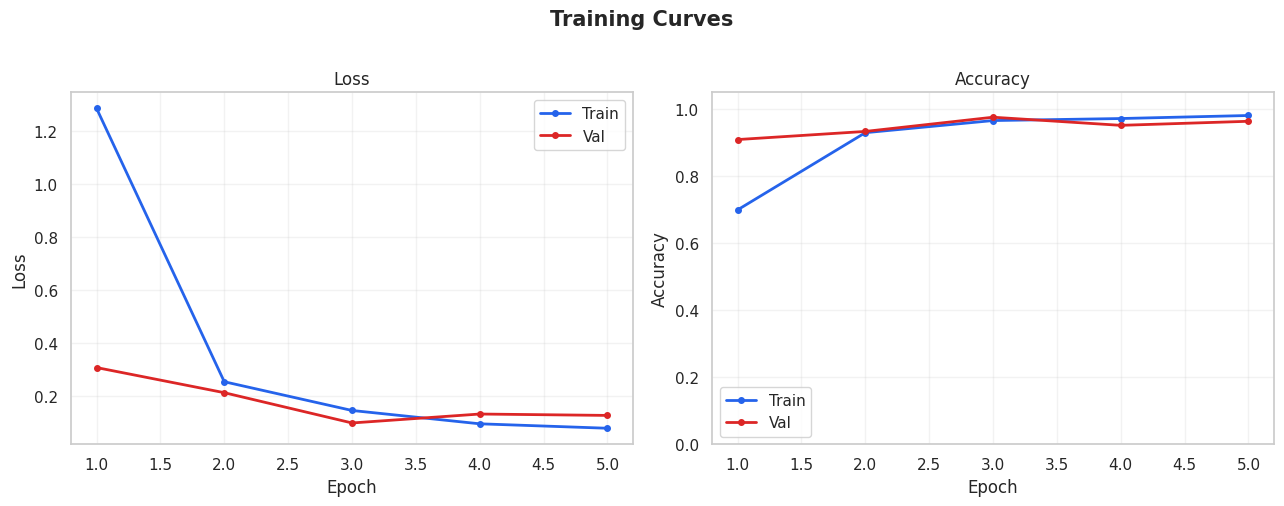

In [44]:
# plot results
plot_training_results(results_vgg_19)

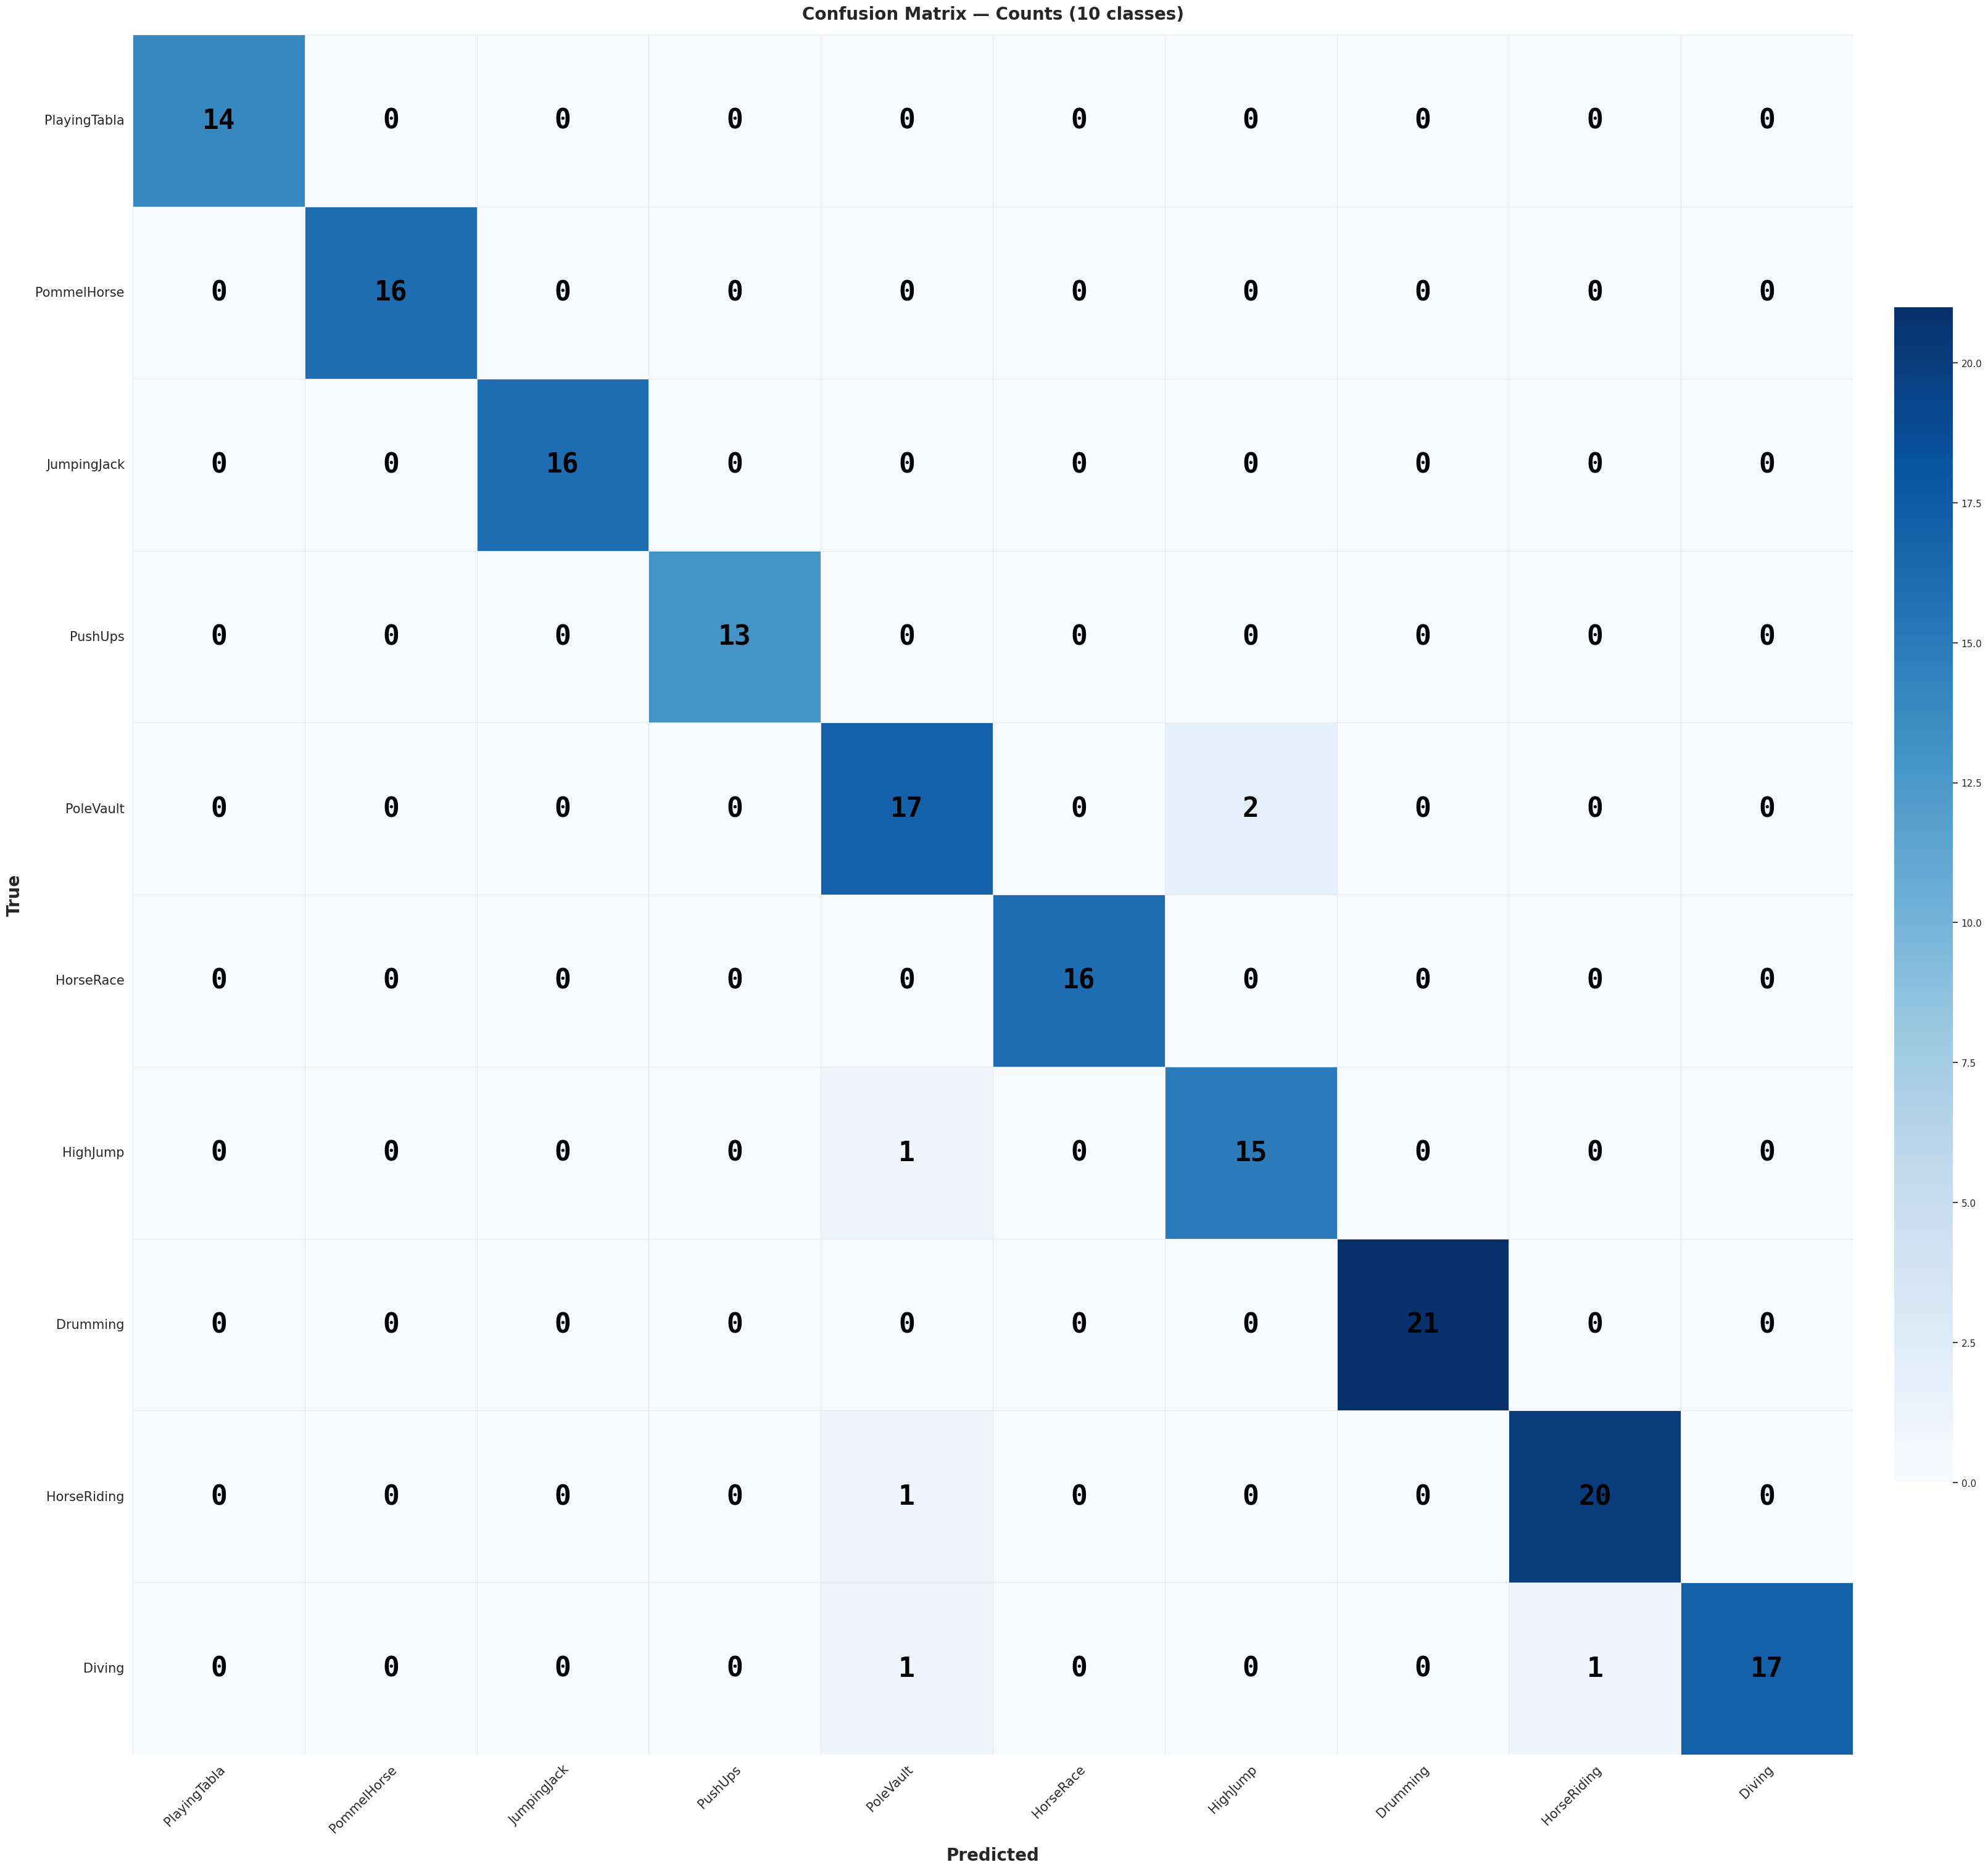

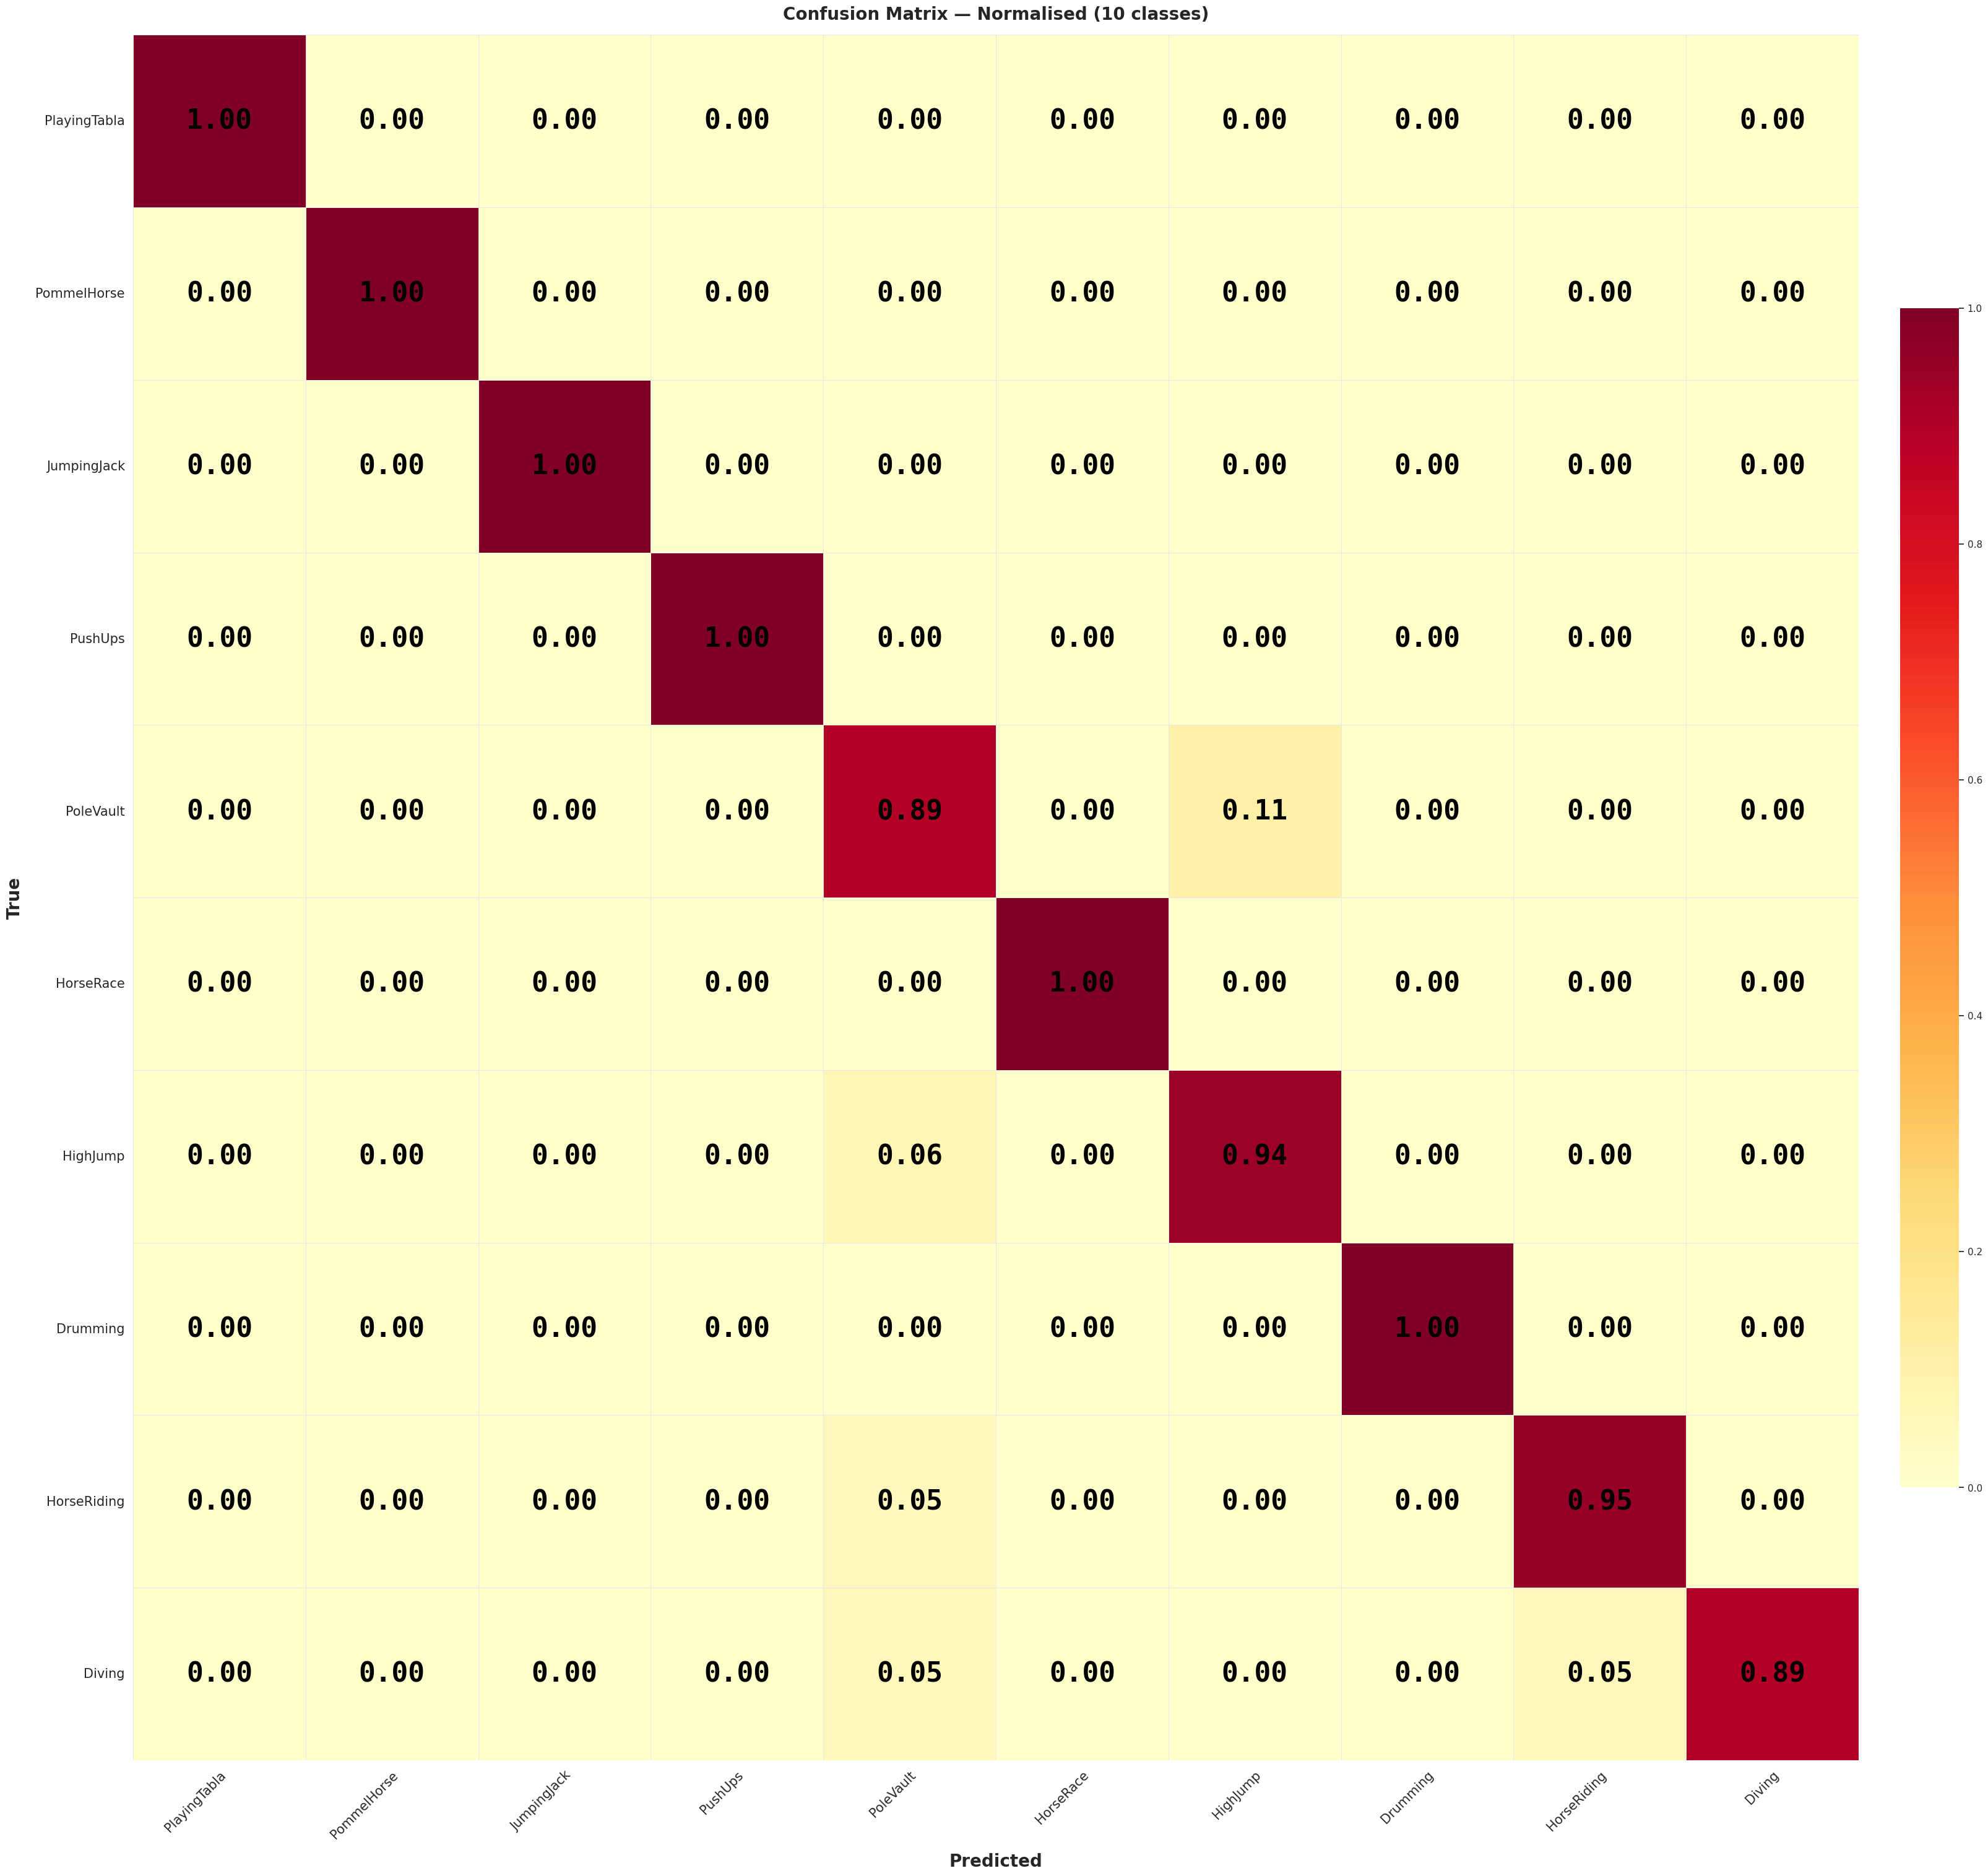

In [45]:
plot_confusion_matrix(all_labels_vgg_19, all_preds_vgg_19, num_classes=10, classes_list=SELECTED_CLASSES)

In [46]:
# print detailed metrics
print_detailed_metrics(all_labels_vgg_19, all_preds_vgg_19, num_classes=10, classes_list=SELECTED_CLASSES)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9649
  Precision : 0.9665
  Recall    : 0.9649
  F1-Score  : 0.9652

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        14
 PommelHorse       1.00      1.00      1.00        16
 JumpingJack       1.00      1.00      1.00        16
     PushUps       1.00      1.00      1.00        13
   PoleVault       0.85      0.89      0.87        19
   HorseRace       1.00      1.00      1.00        16
    HighJump       0.88      0.94      0.91        16
    Drumming       1.00      1.00      1.00        21
 HorseRiding       0.95      0.95      0.95        21
      Diving       1.00      0.89      0.94        19

    accuracy                           0.96       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.96      0.97       171

TOP 5 BEST CLASSES (F1)
  1. HorseRace                : 1.0000
  2. Drumming           

## **EXCTRACT FEATURES & SAVE**

In [47]:
# take off classifier weights ('fc')
filtered_checkpoint = {k: v for k, v in checkpoint.items() if not k.startswith('fc.')}

# take only non-classifier layers
model_ResNet50.load_state_dict(filtered_checkpoint, strict=False)

model_ResNet50.eval()
model_ResNet50.to('cuda' if torch.cuda.is_available() else 'cpu')

ResNet50LSTM(
  (resnet): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(

In [48]:
# Paths for saving features
base_path = '/content/drive/MyDrive/apai/resnet50/features'
os.makedirs(base_path, exist_ok=True)

train_features_path = os.path.join(base_path, "train_features.pt")
train_labels_path   = os.path.join(base_path, "train_labels.pt")
val_features_path   = os.path.join(base_path, "val_features.pt")
val_labels_path     = os.path.join(base_path, "val_labels.pt")
test_features_path  = os.path.join(base_path, "test_features.pt")
test_labels_path    = os.path.join(base_path, "test_labels.pt")

print("Features will be saved in:", base_path)

def extract_features(model, clip_tensor):
    batch_size, seq_len, C, H, W = clip_tensor.shape
    clip_tensor = clip_tensor.to(device)
    with torch.no_grad():
        features = model.resnet(clip_tensor.view(batch_size * seq_len, C, H, W))
        features = features.view(batch_size, seq_len, -1)
        lstm_out, _ = model.lstm(features)
        video_features = lstm_out[:, -1, :]  # last timestep
    return video_features.cpu()

def process_dataloader(dataloader, model, features_file, labels_file):
    all_features = []
    all_labels = []
    for clips, labels in dataloader:
        features = extract_features(model, clips)
        all_features.append(features)
        all_labels.append(labels.cpu())
    all_features = torch.cat(all_features, dim=0)
    all_labels   = torch.cat(all_labels, dim=0)
    torch.save(all_features, features_file)
    torch.save(all_labels, labels_file)
    print(f"Saved features to {features_file}")
    print(f"Saved labels to {labels_file}")
    return all_features, all_labels

# exctract features for each train, val, test
train_features, train_labels = process_dataloader(train_loader, model_ResNet50, train_features_path, train_labels_path)
val_features, val_labels     = process_dataloader(val_loader, model_ResNet50, val_features_path, val_labels_path)
test_features, test_labels   = process_dataloader(test_loader, model_ResNet50, test_features_path, test_labels_path)

Features will be saved in: /content/drive/MyDrive/apai/resnet50/features


NameError: name 'train_loader' is not defined